In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import zarr
from scipy.optimize import curve_fit
import os
import sys
import glob
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [47]:
root = Path('/Volumes/data/Sasaki/MTsingleBeads')
#root = Path('/mnt/NAS-Ebanaru/sasaki/MTsingleBeads')

def exp_fit(x, A, xi, y0):
    return A*np.exp(-x/xi) + y0

def exp_fit_constrained(x, xi, C):
    """x = 0 のときに必ず 1 になる指数フィッティング関数"""
    return (1 - C) * np.exp(-x/xi) + C


def func(root, folder):

    particles = []
    bgs = []

    for input_dir in glob.glob(str(root / folder / "*"/ "*")):
        input_dir = Path(input_dir)
        if os.path.isfile(input_dir):
            continue
        #print(input_dir)
        particle= xr.open_zarr(input_dir / "local_polar_w.zarr")
        bg = xr.open_zarr(input_dir / "local_polar_bg.zarr")
        p_mean = particle.polar_order.mean(dim=['frame', 'particle'])
        bg_mean = bg.polar_order.mean(dim=['frame'])

        particles.append(p_mean)
        bgs.append(bg_mean)

    return particles, bgs

def func_no(root, folder):

    particles = []

    print(root/folder)
    print(glob.glob(str(root / folder / "*"/ "*")))
    for input_dir in glob.glob(str(root / folder / "*"/ "*")):
        input_dir = Path(input_dir)
        if os.path.isfile(input_dir):
            continue
        print(input_dir)
        particle= xr.open_zarr(input_dir / "local_polar_noCargo.zarr")
        p_mean = particle.polar_order.mean(dim=['frame'])

        particles.append(p_mean)

    return particles

def make_df(particles, bgs):
    p_list = []
    bg_list = []

    min_size = min([len(np.array(p)) for p in particles] + 
                   [len(np.array(bg)) for bg in bgs] + 
                   [len(np.array(particles[0]['window size'])), len(np.array(bgs[0]['window size']))])

    i = 0
    for particle in particles:
        p_df = {'window_size':[], 'polar_order':[], 'exp':[]}
        p_mean = np.array(particle)[:min_size]
        p_df['window_size'] = np.array(particles[0]['window size'])[:min_size]
        p_df['polar_order'] = p_mean
        p_df['exp'] = i
        i += 1
        p_df = pd.DataFrame(p_df)
        p_list.append(p_df)
    i = 0
    for bg in bgs:
        bg_df = {'window_size':[], 'polar_order':[], 'exp':[]}
        bg_mean = np.array(bg)[:min_size]
        bg_df['window_size'] = np.array(bgs[0]['window size'])[:min_size]
        bg_df['polar_order'] = bg_mean
        bg_df['exp'] = i
        i += 1
        bg_df = pd.DataFrame(bg_df)
        bg_list.append(bg_df)

    p_concat = pd.concat(p_list, ignore_index=True)
    bg_concat = pd.concat(bg_list, ignore_index=True)

    return p_concat, bg_concat

def make_df_no(particles):
    p_list = []

    min_size = min([len(np.array(p)) for p in particles] + 
                   [len(np.array(particles[0]['window size']))])

    i = 0
    for particle in particles:
        p_df = {'window_size':[], 'polar_order':[], 'exp':[]}
        p_mean = np.array(particle)[:min_size]
        p_df['window_size'] = np.array(particles[0]['window size'])[:min_size]
        p_df['polar_order'] = p_mean
        p_df['exp'] = i
        i += 1
        p_df = pd.DataFrame(p_df)
        p_list.append(p_df)

    p_concat = pd.concat(p_list, ignore_index=True)

    return p_concat

def plot_polar(df, ax=None, label=None, marker='o', linestyle='none', color=None, scale = 0.11, lw = 3.0, zorder = 1, fitting = False, fitting_ls = '-' ,min_window=1, max_window=10):
    if ax is None:
        ax = plt.gca()

    window_size = df['window_size'].unique() * scale
    polar_order = np.array(df.groupby('window_size').mean()['polar_order'])
    std = df.groupby('window_size').std()['polar_order']

    ax.errorbar(window_size, polar_order, yerr=std, label=label, marker=marker, linestyle=linestyle, color=color, lw = lw, zorder=zorder)

    if fitting:
        indices = np.where((window_size>min_window) & (window_size<max_window))    
        polar_order=np.array(polar_order)
        popt, pcov = curve_fit(exp_fit_constrained, window_size[indices], polar_order[indices])
        x_axis = np.linspace(0, 100, 1000)
        ax.plot(x_axis, exp_fit_constrained(x_axis, *popt), color = color, linestyle=fitting_ls)

        return window_size, polar_order, std, popt, pcov

    return window_size, polar_order, std


In [41]:
particles06um, bgs06um = func(root, "beads06um")
df_p06, df_bg06 = make_df(particles06um, bgs06um)
particles1um, bgs1um = func(root, "beads1um")
df_p1, df_bg1 = make_df(particles1um, bgs1um)
particles3um, bgs3um = func(root, "beads3um")
df_p3, df_bg3 = make_df(particles3um, bgs3um)
particles5um, bgs5um = func(root, "beads5um")
df_p5, df_bg5 = make_df(particles5um, bgs5um)
particles7um, bgs7um = func(root, "beads7um")
df_p7, df_bg7 = make_df(particles7um, bgs7um)

no = func_no(root, "control/MTs8uM")
df_no = make_df_no(no)

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_17572/2644326334.py:22: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  particle= xr.open_zarr(input_dir / "local_polar_w.zarr")
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_17572/2644326334.py:23: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this exist

/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM
['/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM/20260624/MTs8uM.nd2', '/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM/20260624/MTs8uM001.nd2', '/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM/20260624/MTs8uM002.nd2', '/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM/20260624/MTs8uM', '/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM/20260624/MTs8uM001', '/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM/20260624/MTs8uM002']
/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM/20260624/MTs8uM


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_17572/2644326334.py:43: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  particle= xr.open_zarr(input_dir / "local_polar_noCargo.zarr")


/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM/20260624/MTs8uM001


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_17572/2644326334.py:43: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  particle= xr.open_zarr(input_dir / "local_polar_noCargo.zarr")


/Volumes/data/Sasaki/MTsingleBeads/control/MTs8uM/20260624/MTs8uM002


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_17572/2644326334.py:43: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  particle= xr.open_zarr(input_dir / "local_polar_noCargo.zarr")


In [7]:
df_p5 = df_p5[df_p5['window_size']!=20]

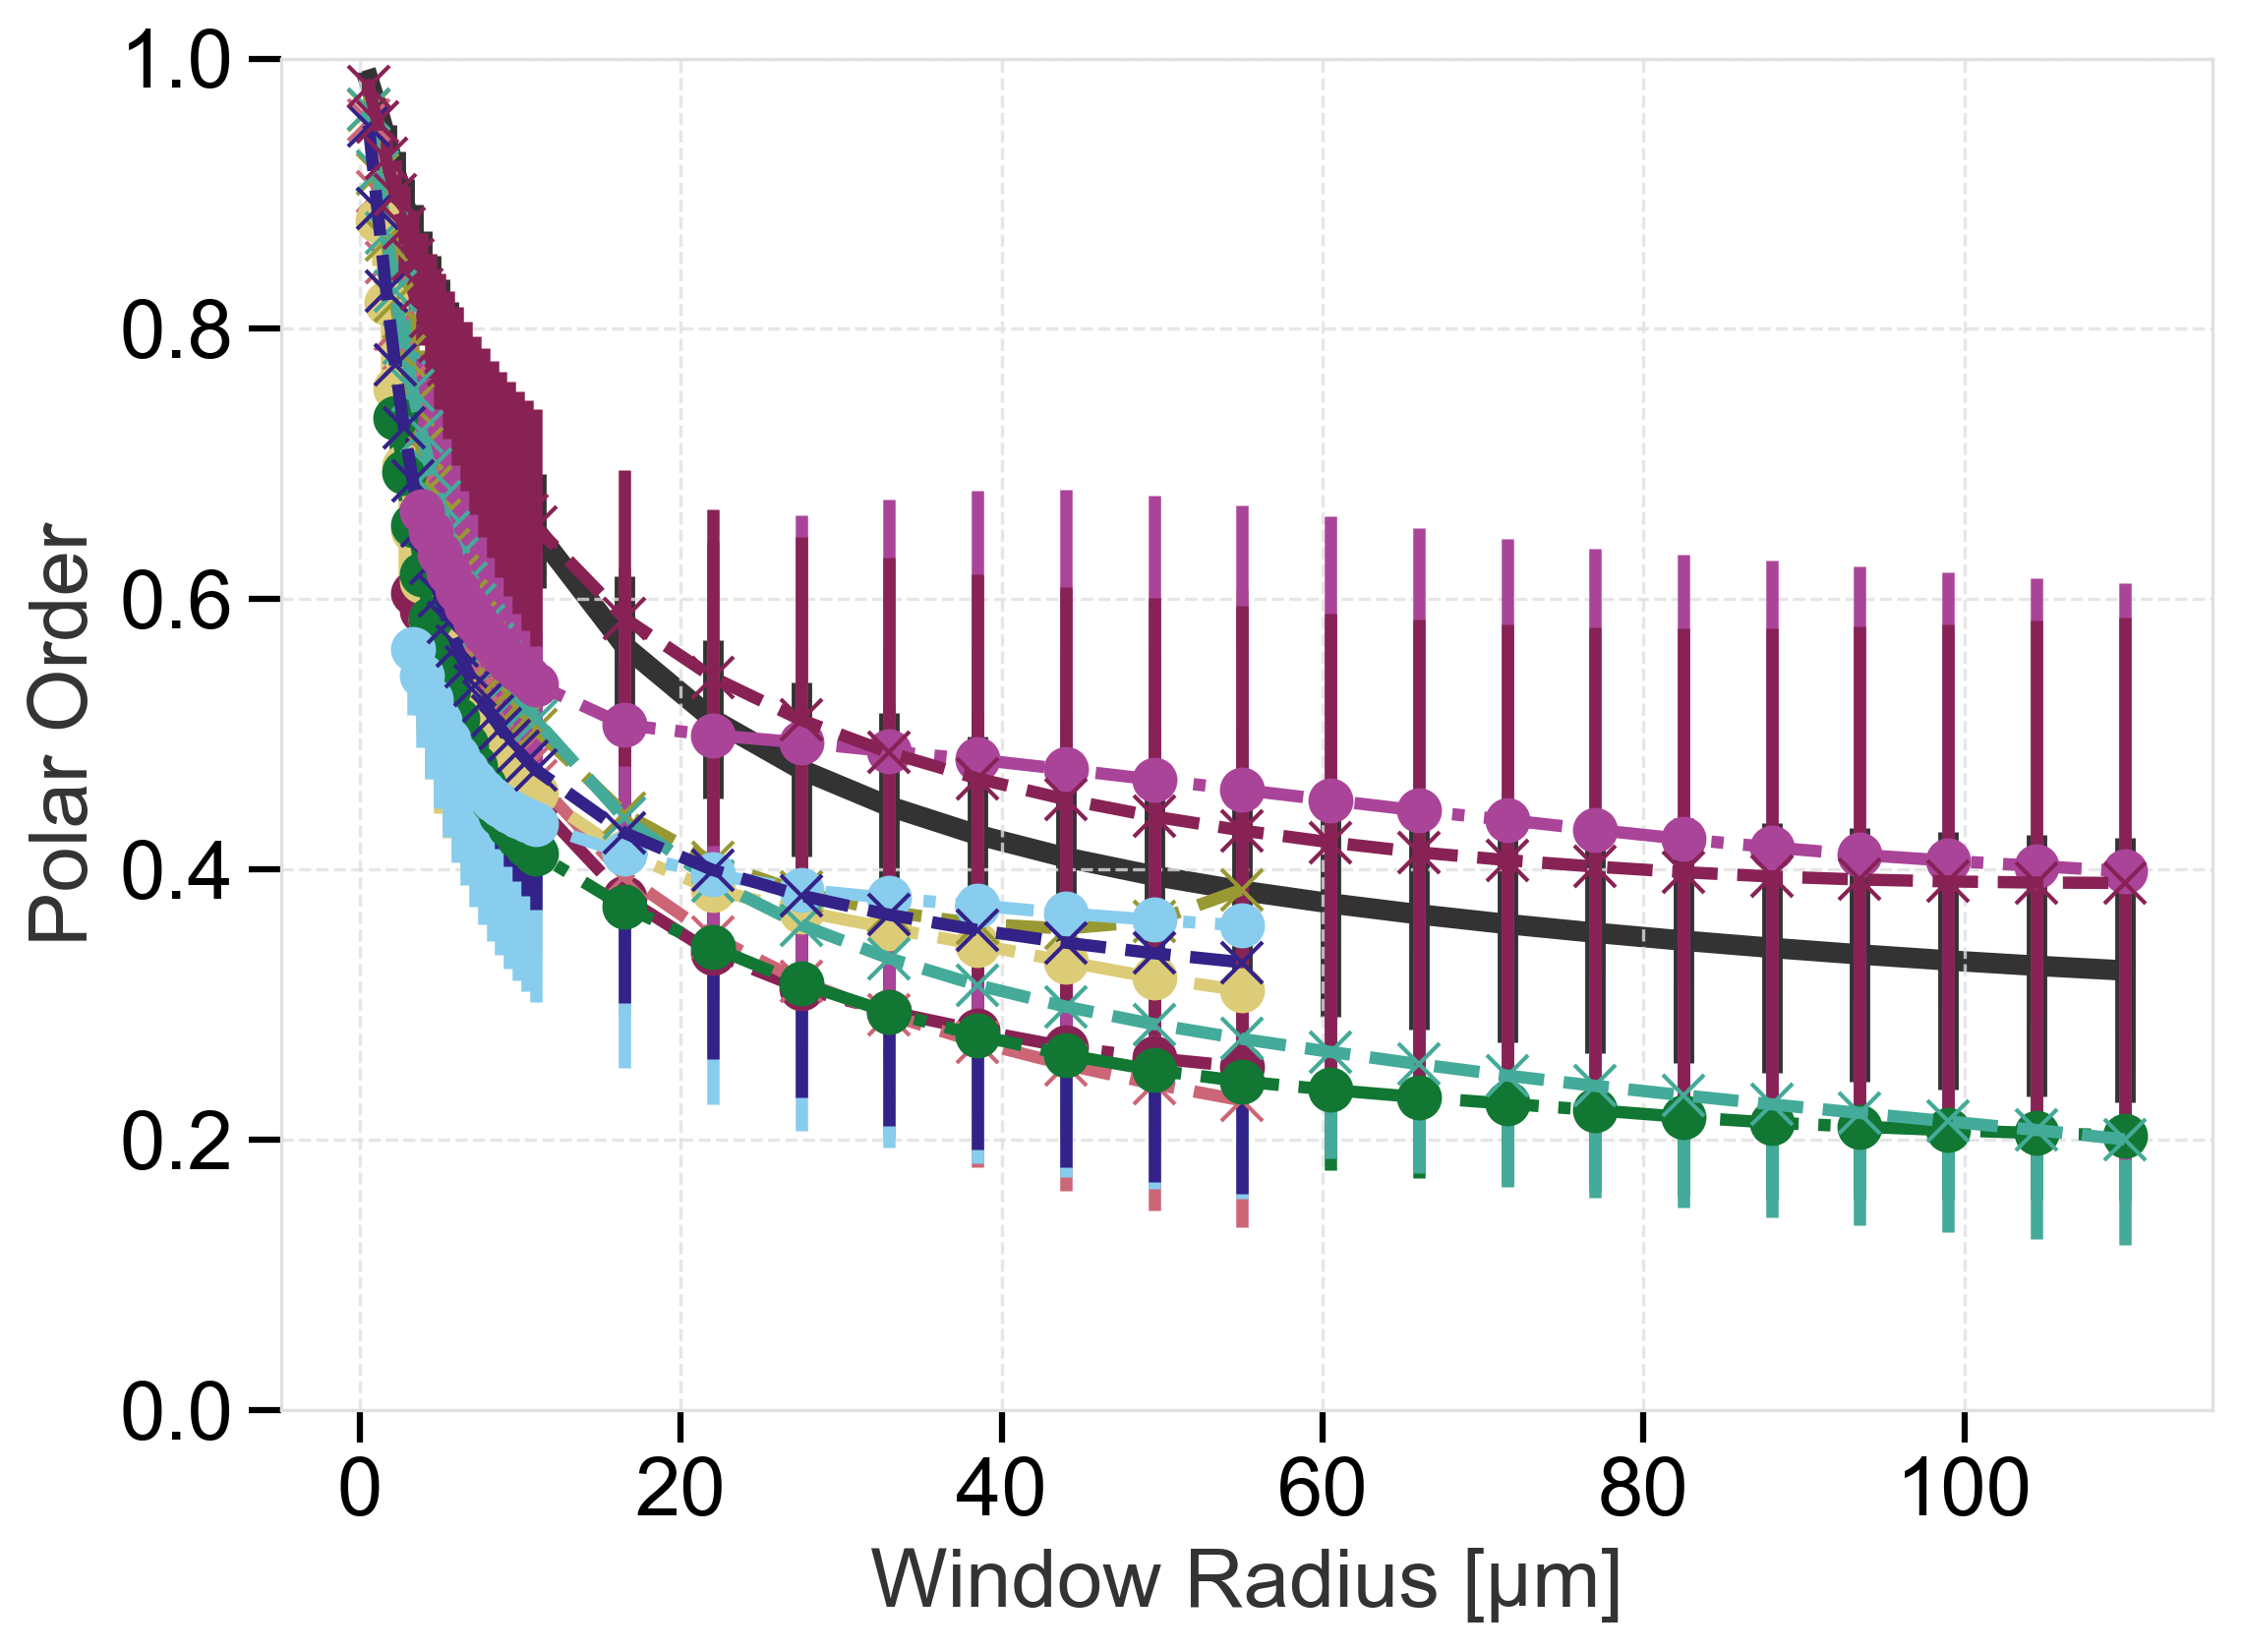

In [8]:
fig, ax = plt.subplots()
plot_polar(df_p06, ax=ax, label='0.63 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg06, ax=ax, label='0.63 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', linestyle='--')
w, p,s=plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', linestyle='--')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5, zorder =-1)

ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar.svg")

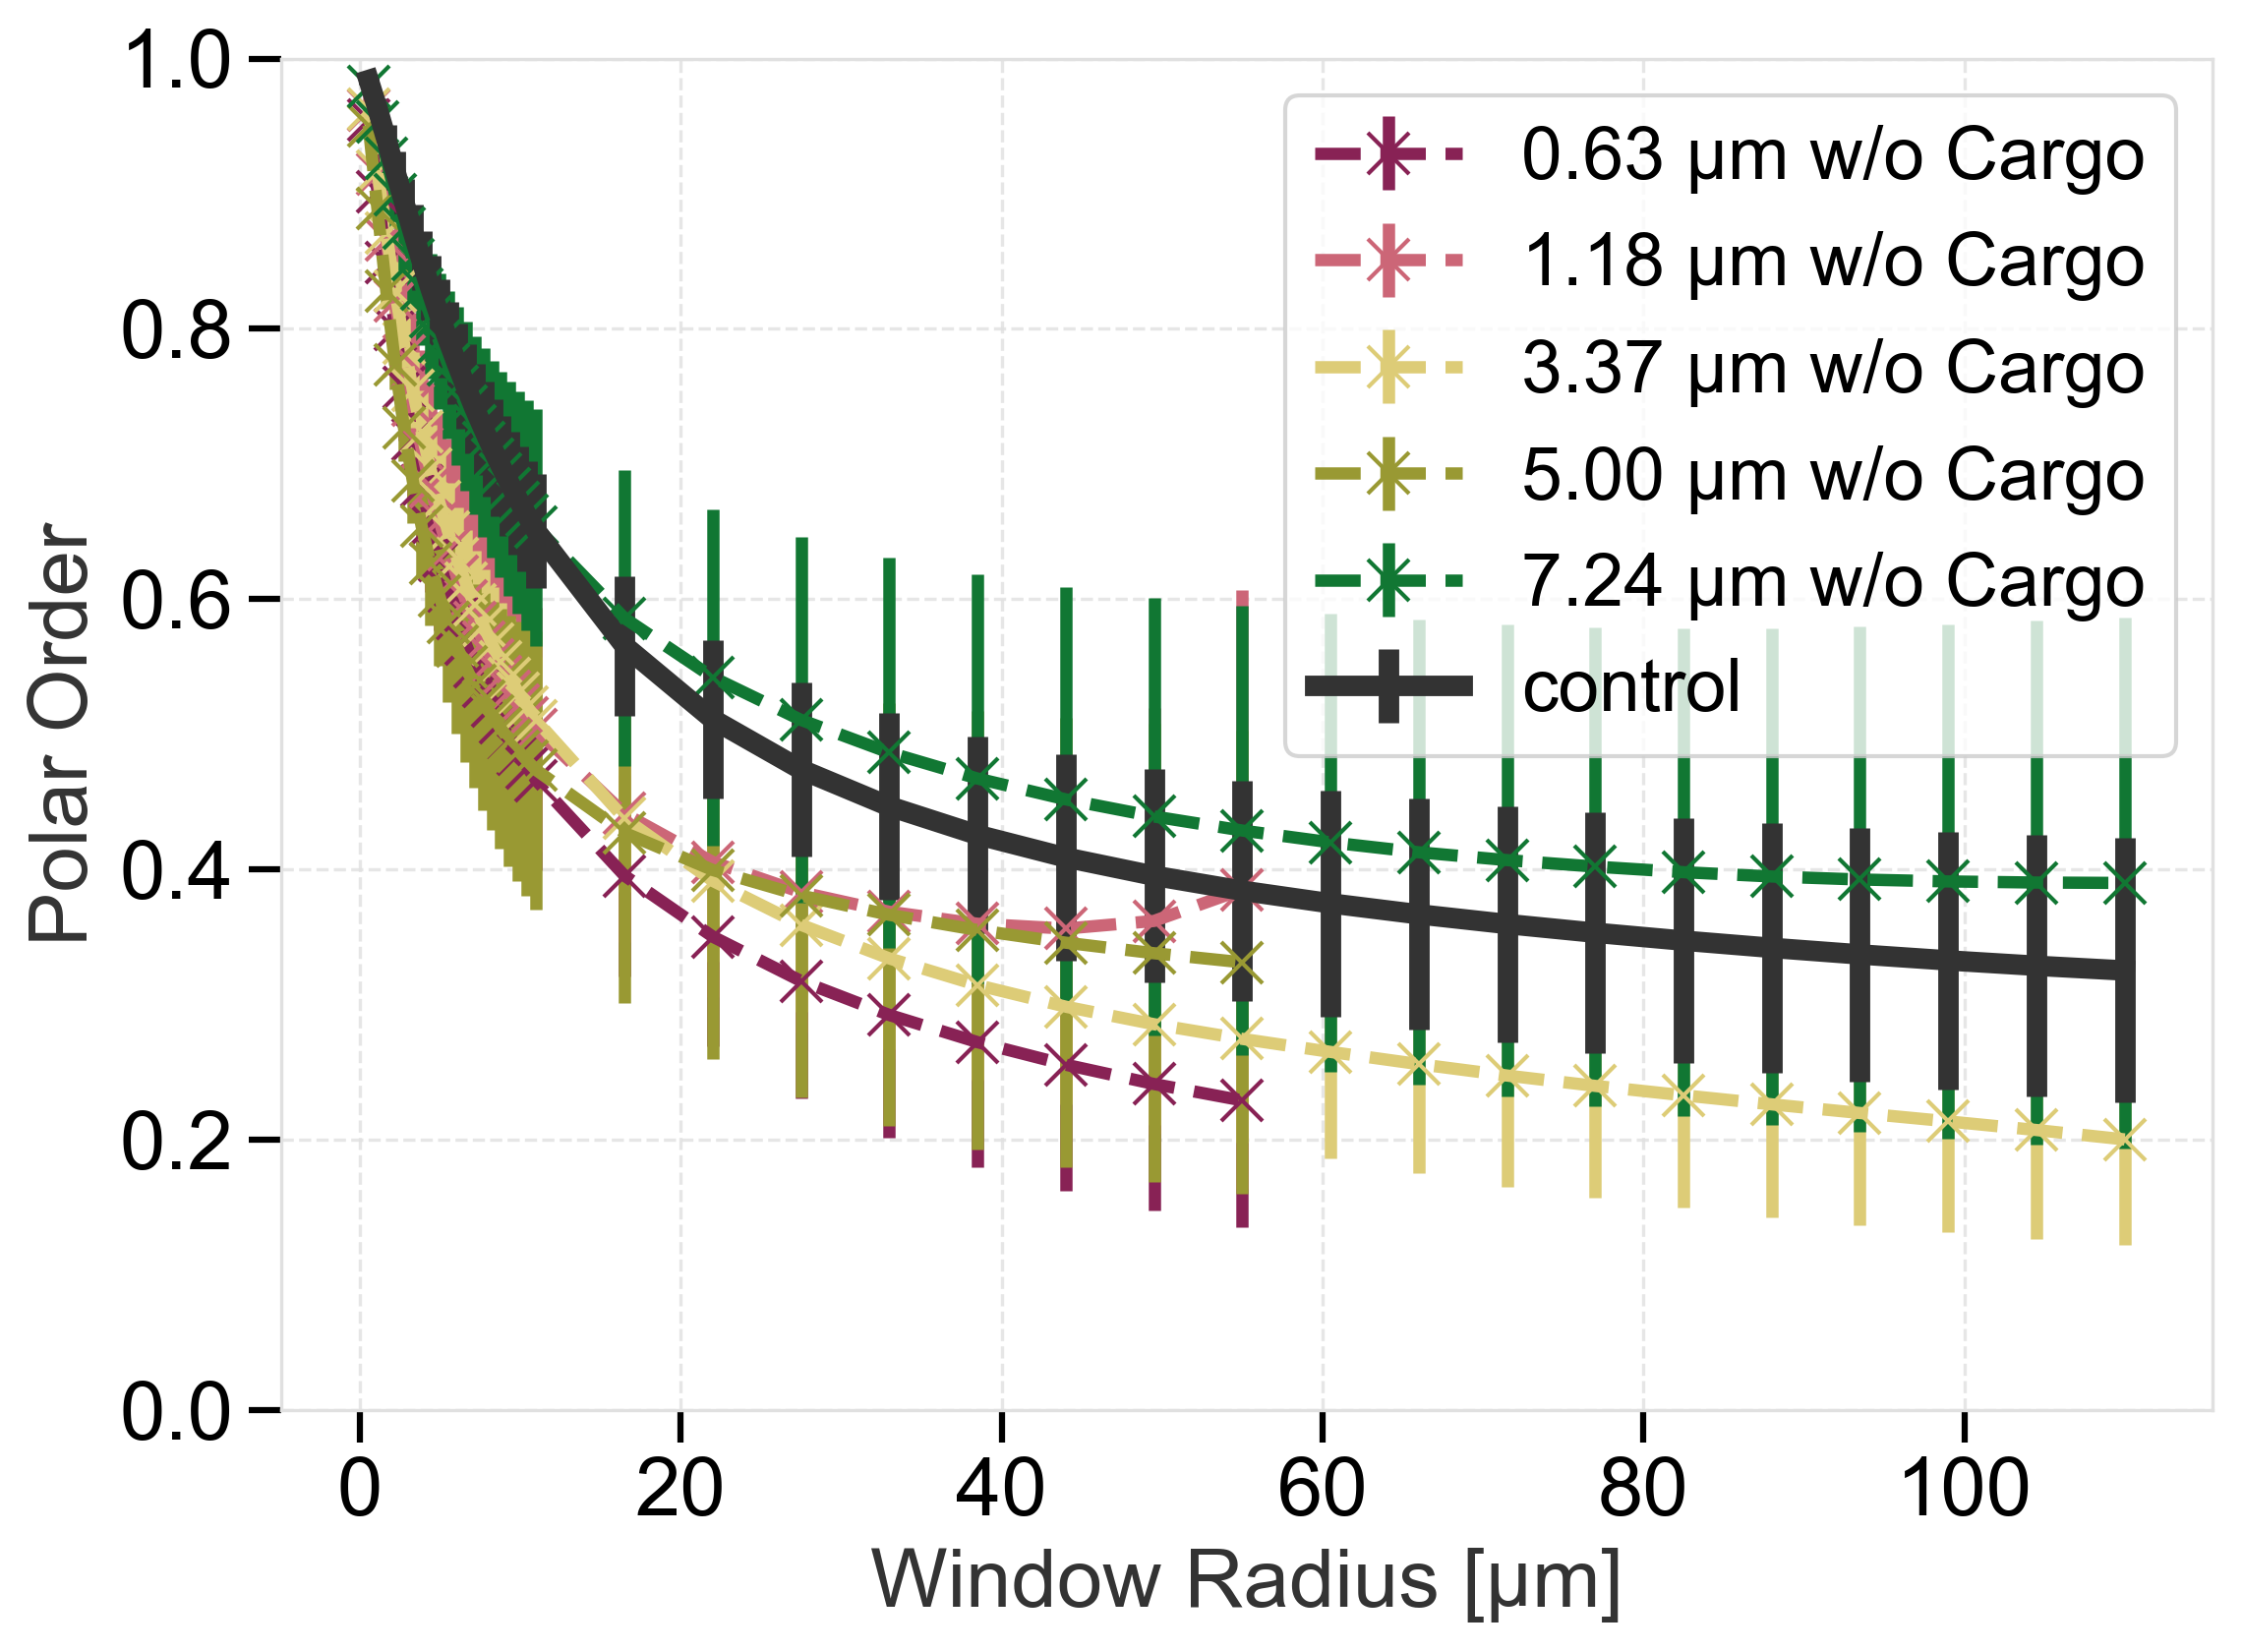

In [9]:
fig, ax = plt.subplots()

plot_polar(df_bg06, ax=ax, label='0.63 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', linestyle='--')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5)

ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_wo.svg")

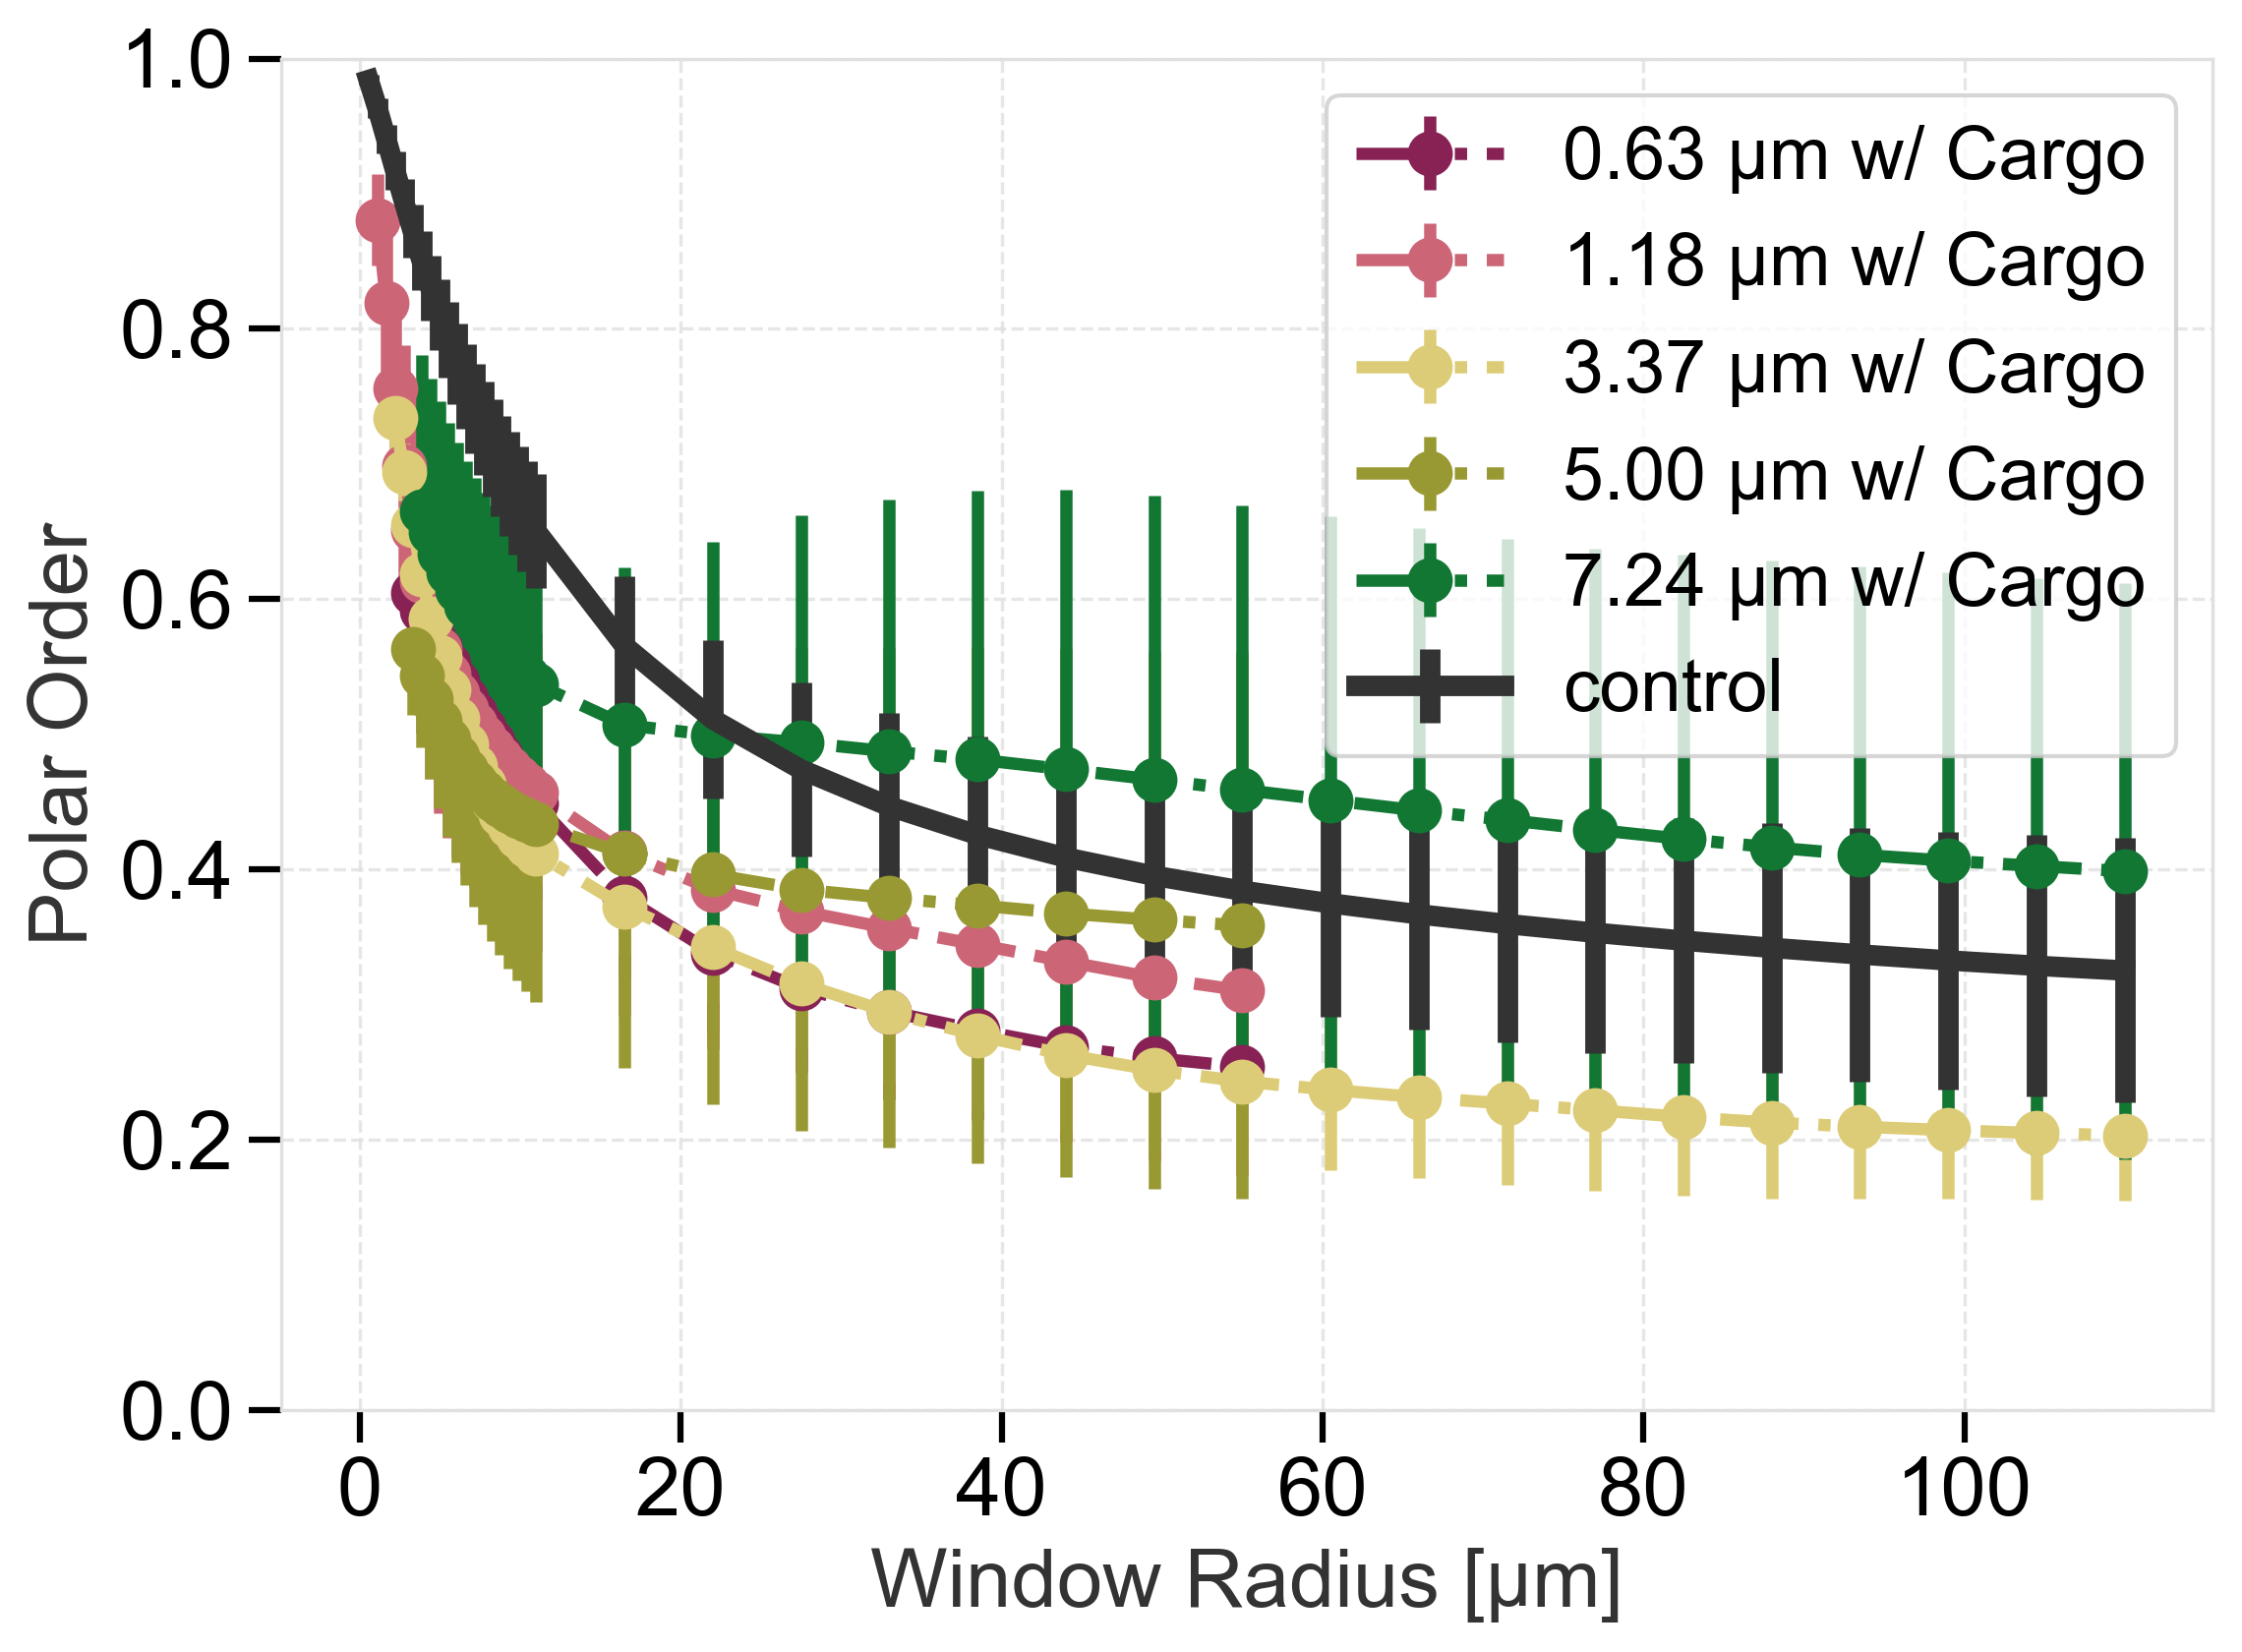

In [10]:
fig, ax = plt.subplots()

plot_polar(df_p06, ax=ax, label='0.63 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5)

ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_w.svg")

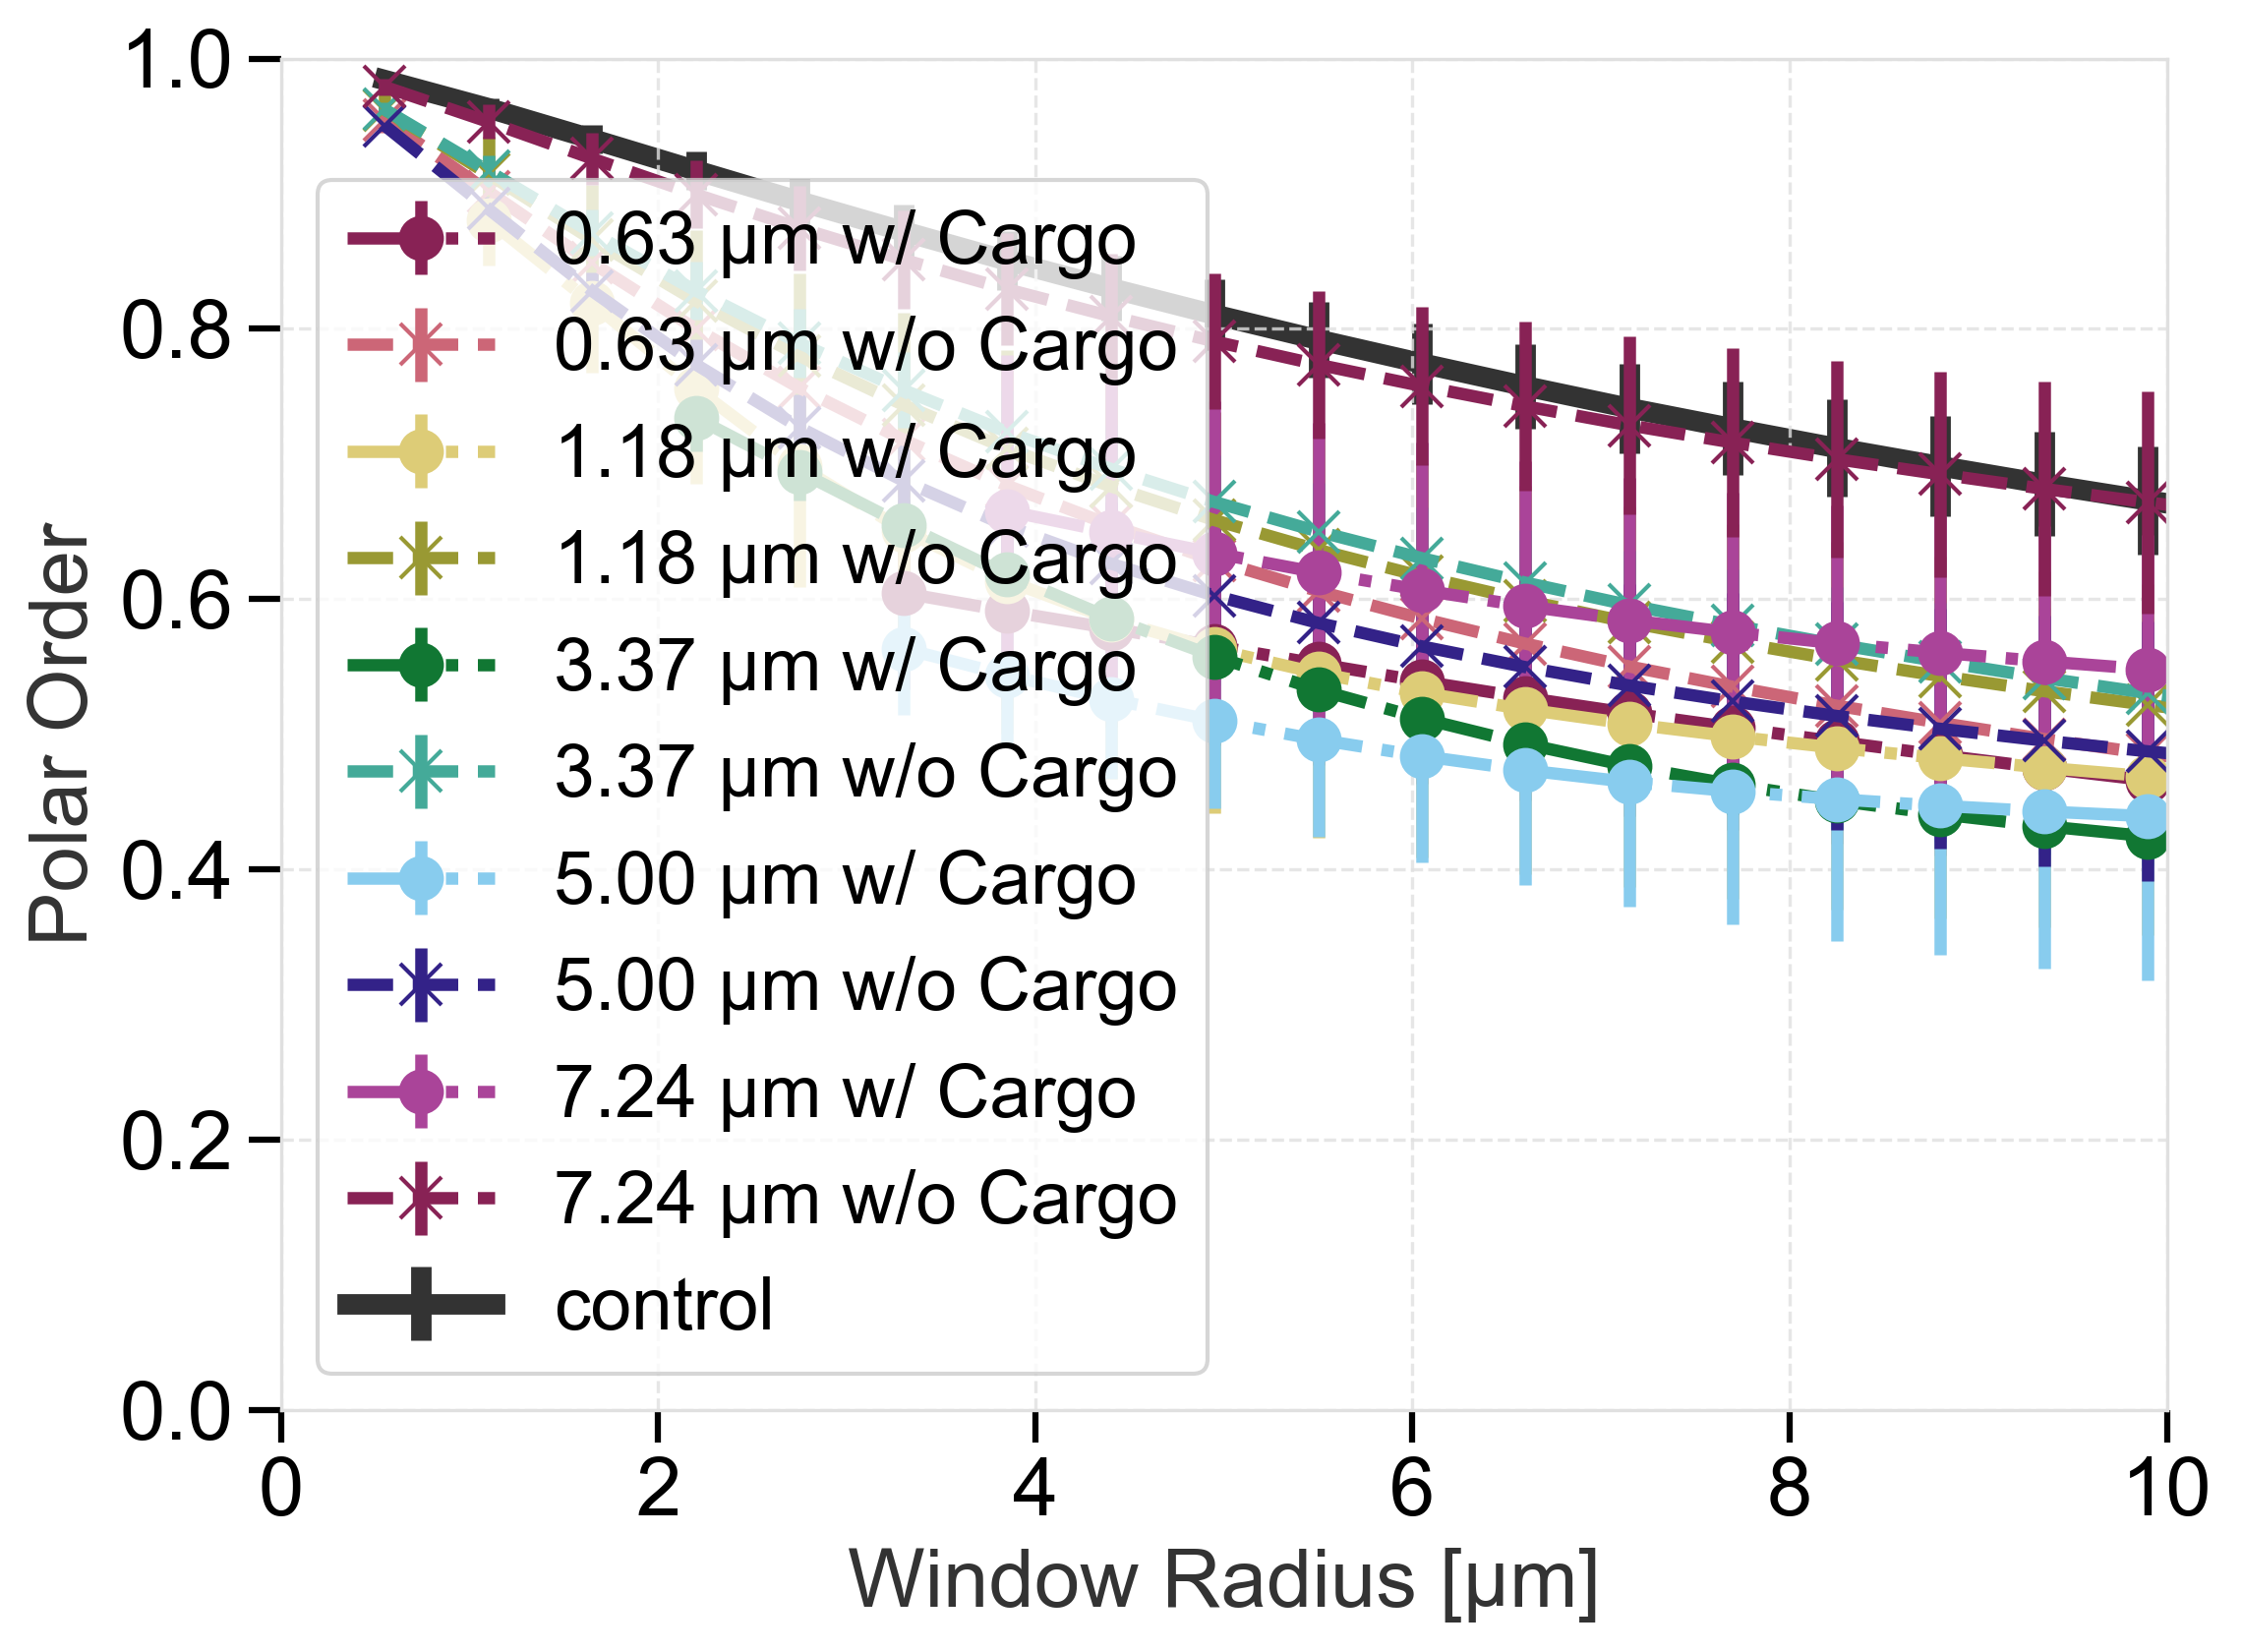

In [11]:
fig, ax = plt.subplots()

plot_polar(df_p06, ax=ax, label='0.63 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg06, ax=ax, label='0.63 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', linestyle='--')
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', linestyle='--')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5, zorder=-1)


ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom.svg")

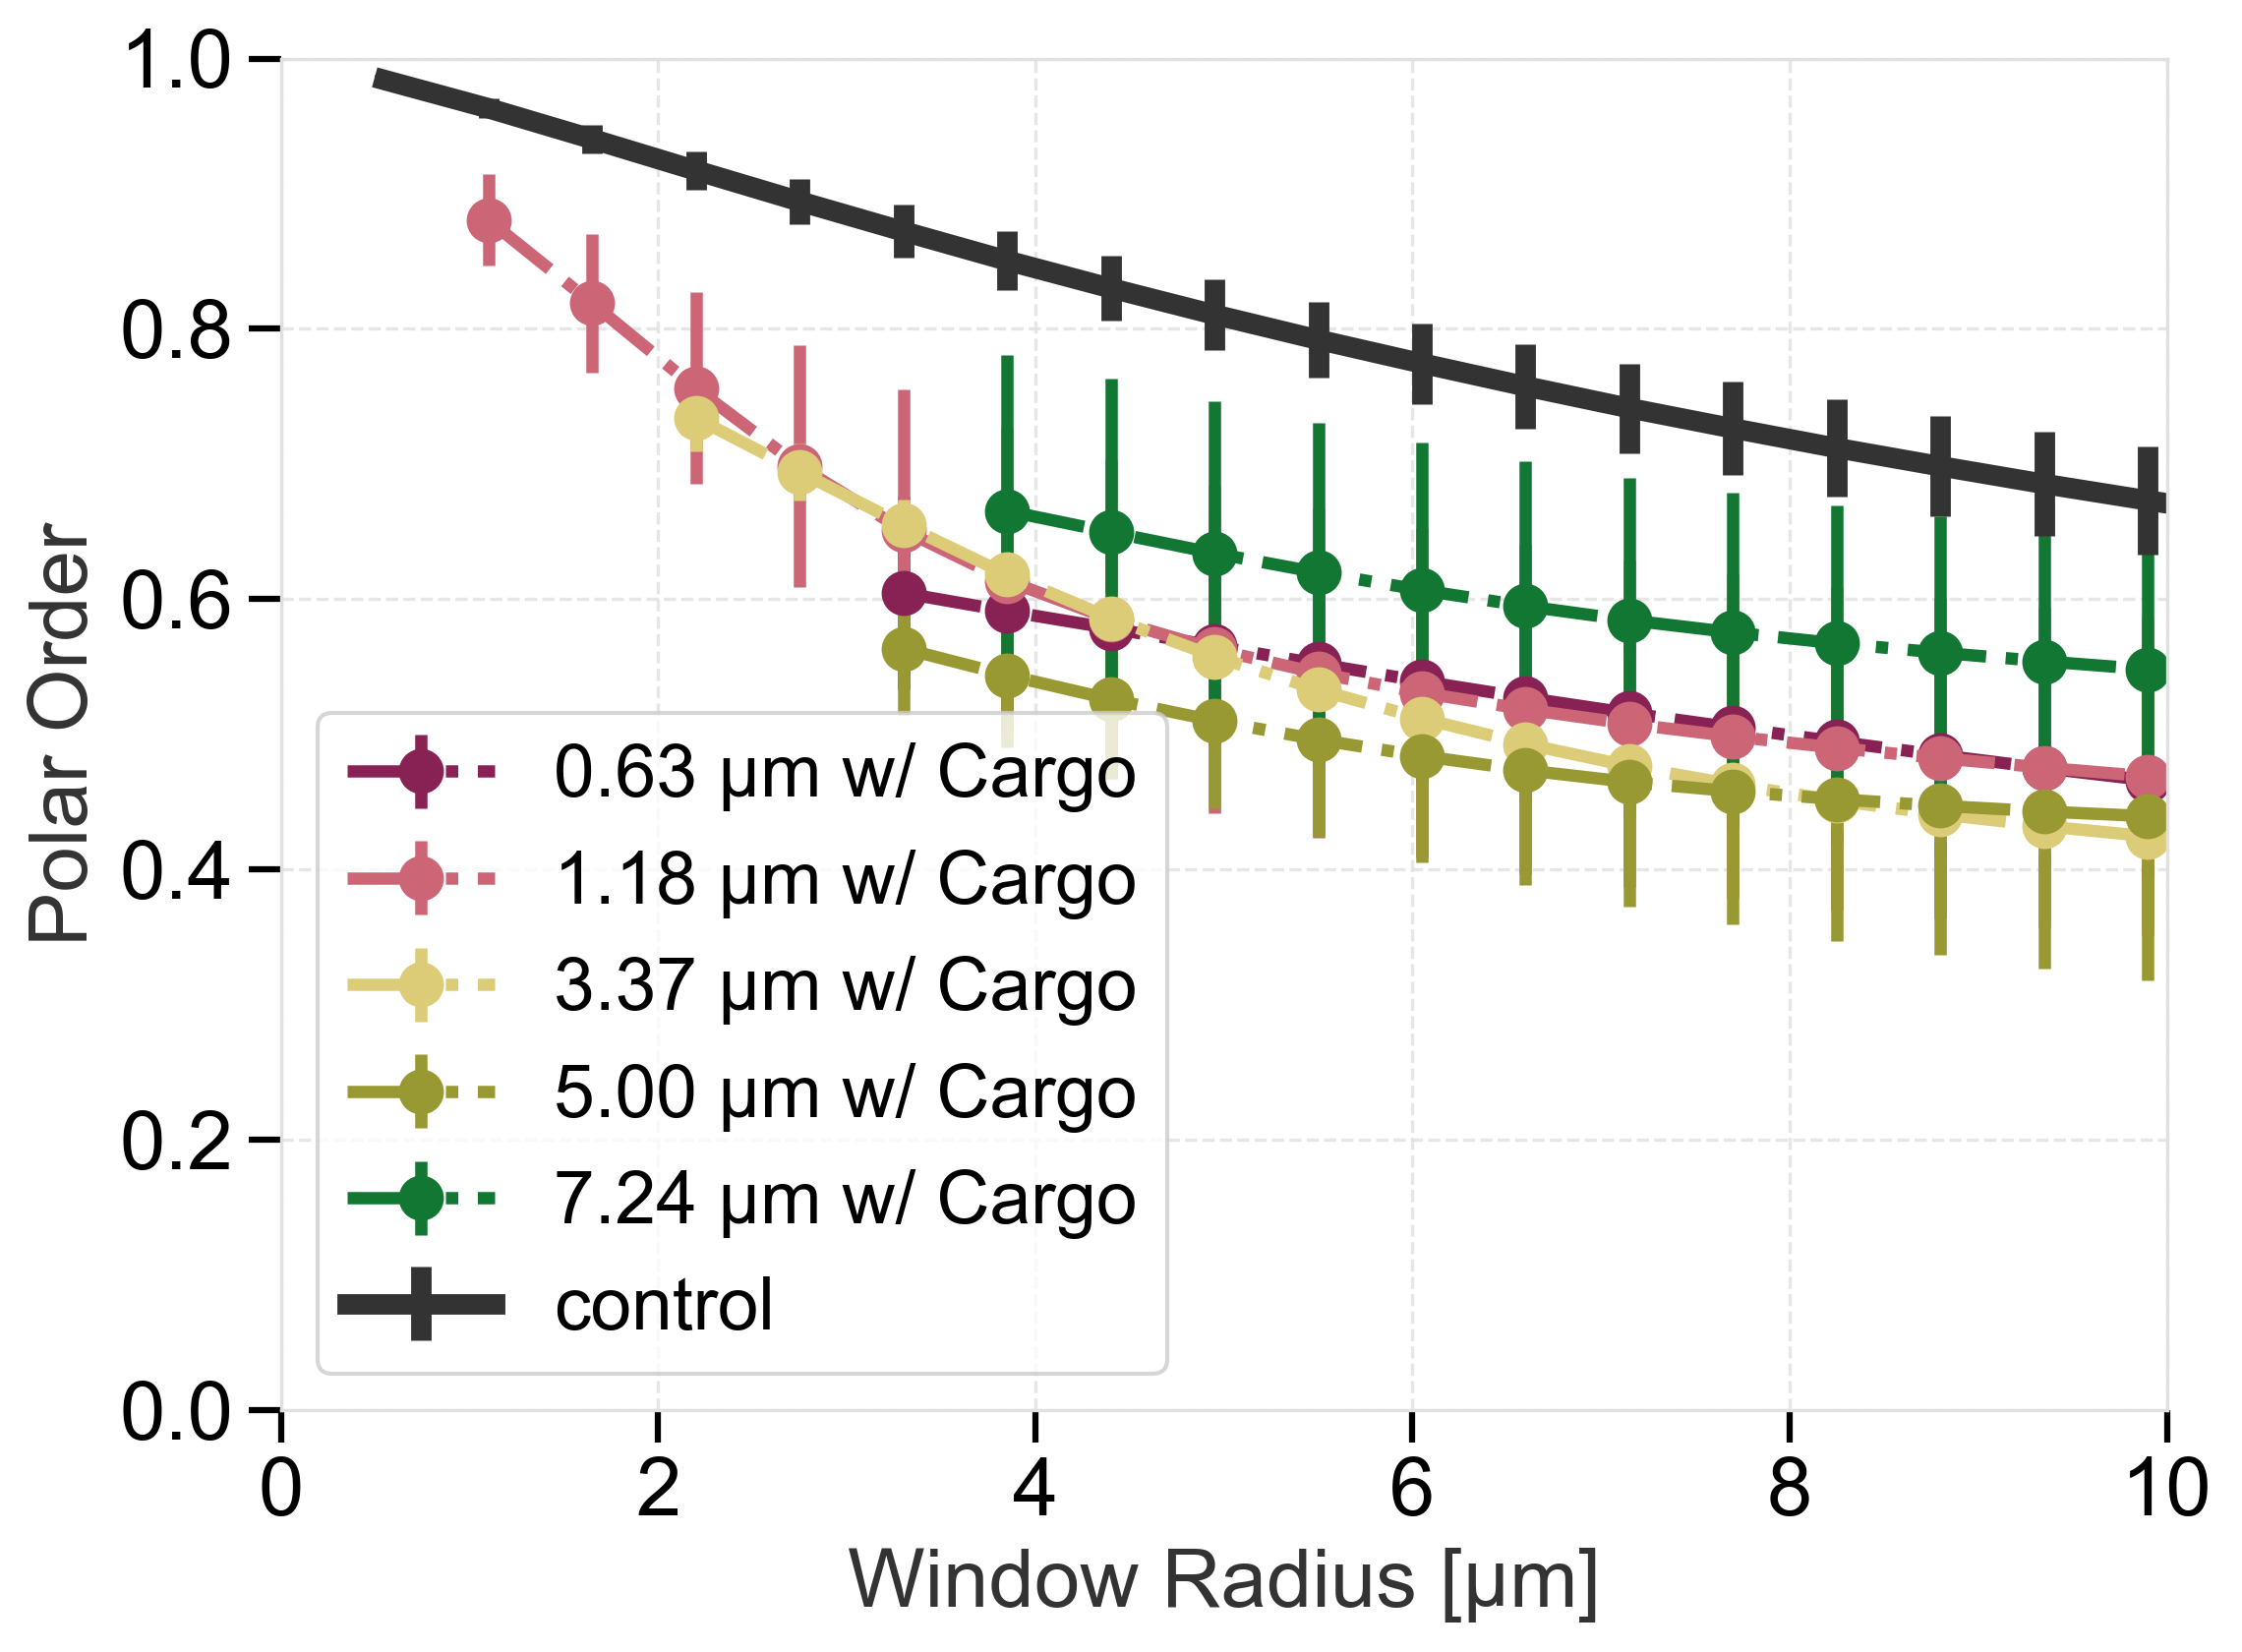

In [ ]:
fig, ax = plt.subplots()
plot_polar(df_p06, ax=ax, label='0.63 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.')
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5)

ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_w_zoom.svg")

xi 5.487499607953743
xi 5.883430890740195
xi 6.261930092532823
xi 4.25902223653334
xi 9.852849626219138


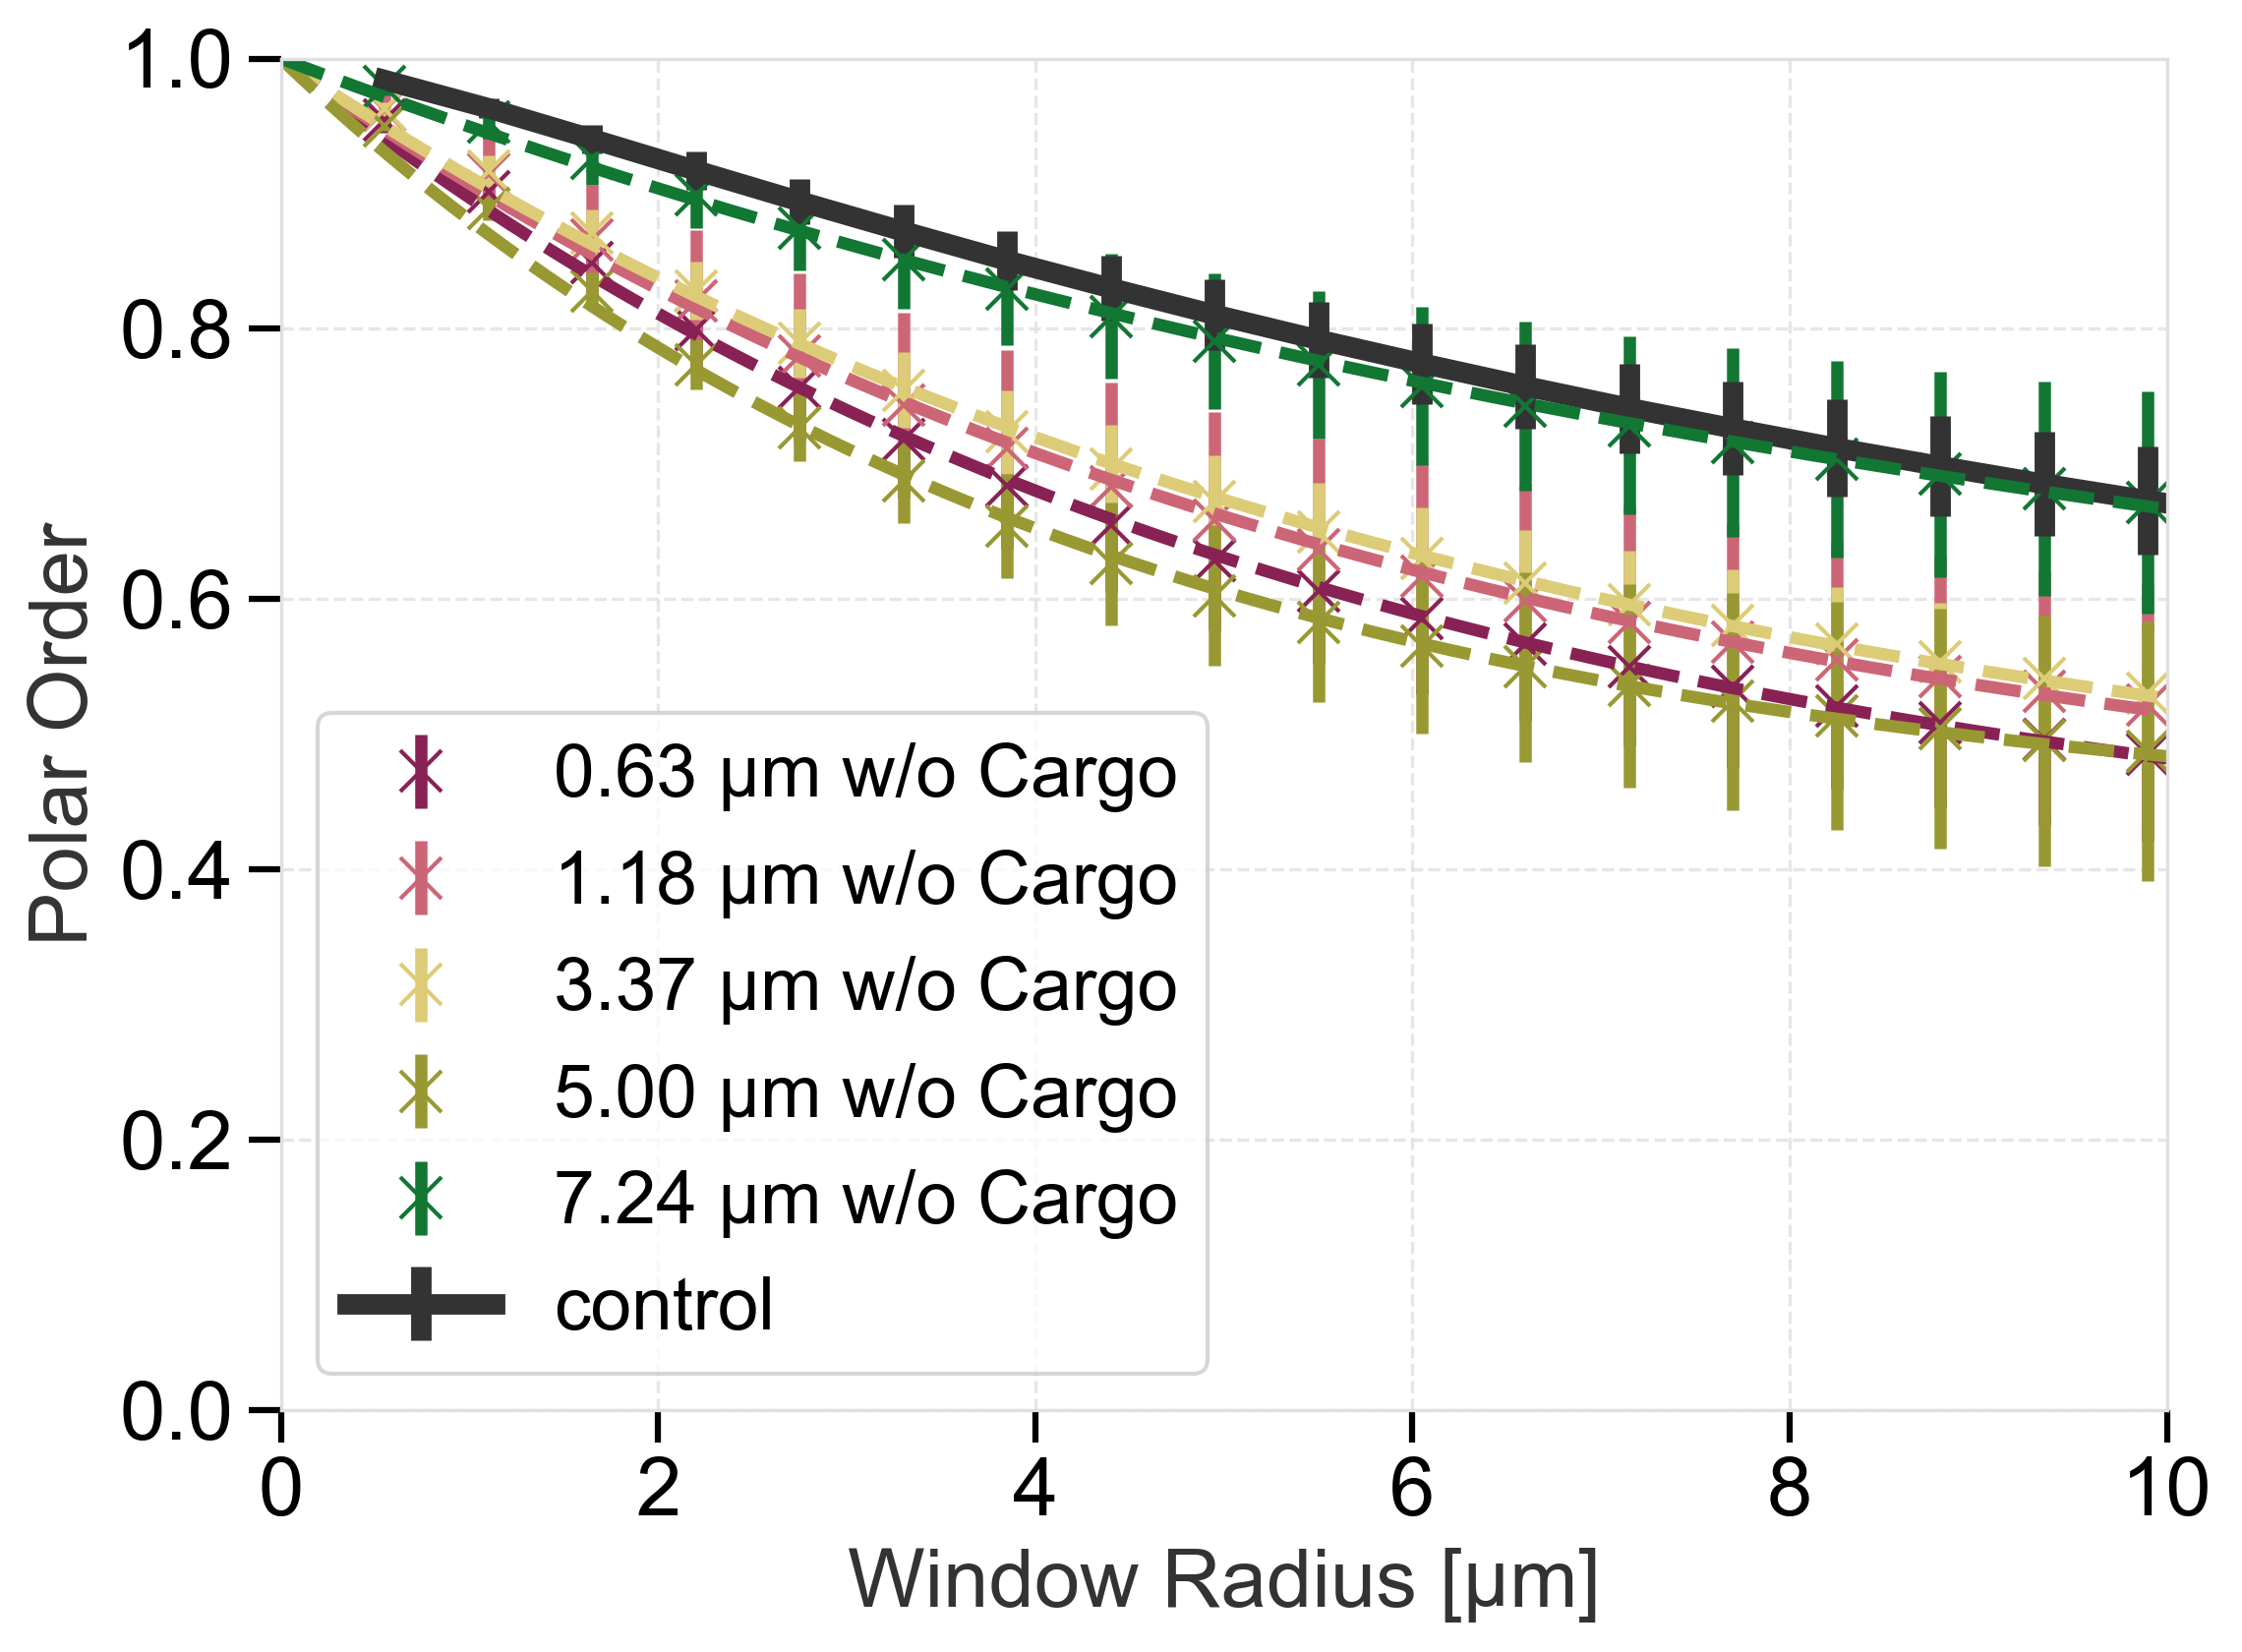

In [64]:
fig, ax = plt.subplots()

_, _, _, popt_bg06, _ = plot_polar(df_bg06, ax=ax, label='0.63 \u03bcm w/o Cargo', marker='x', color=style_colors[0], fitting = True, min_window=1, max_window=10, fitting_ls='--')
_, _, _, popt_bg1, _ = plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', color=style_colors[1], fitting = True, min_window=1, max_window=10, fitting_ls='--')
_, _, _, popt_bg3, _ = plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', color=style_colors[2], fitting = True, min_window=1, max_window=10, fitting_ls='--')
_, _, _, popt_bg5, _ = plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', color=style_colors[3], fitting = True, min_window=1, max_window=10, fitting_ls='--')
_, _, _, popt_bg7, _ = plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', color=style_colors[4], fitting = True, min_window=1, max_window=10, fitting_ls='--')

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5)

popt_list_bg = [popt_bg06[0], popt_bg1[0], popt_bg3[0], popt_bg5[0], popt_bg7[0]]

for i in popt_list_bg:
    print('xi', i)

ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_wo_zoom.svg")

xi 3.6062200660256383
xi 3.256130049579458
xi 4.079277535064441
xi 2.6112863246665543
xi 3.523412953374126


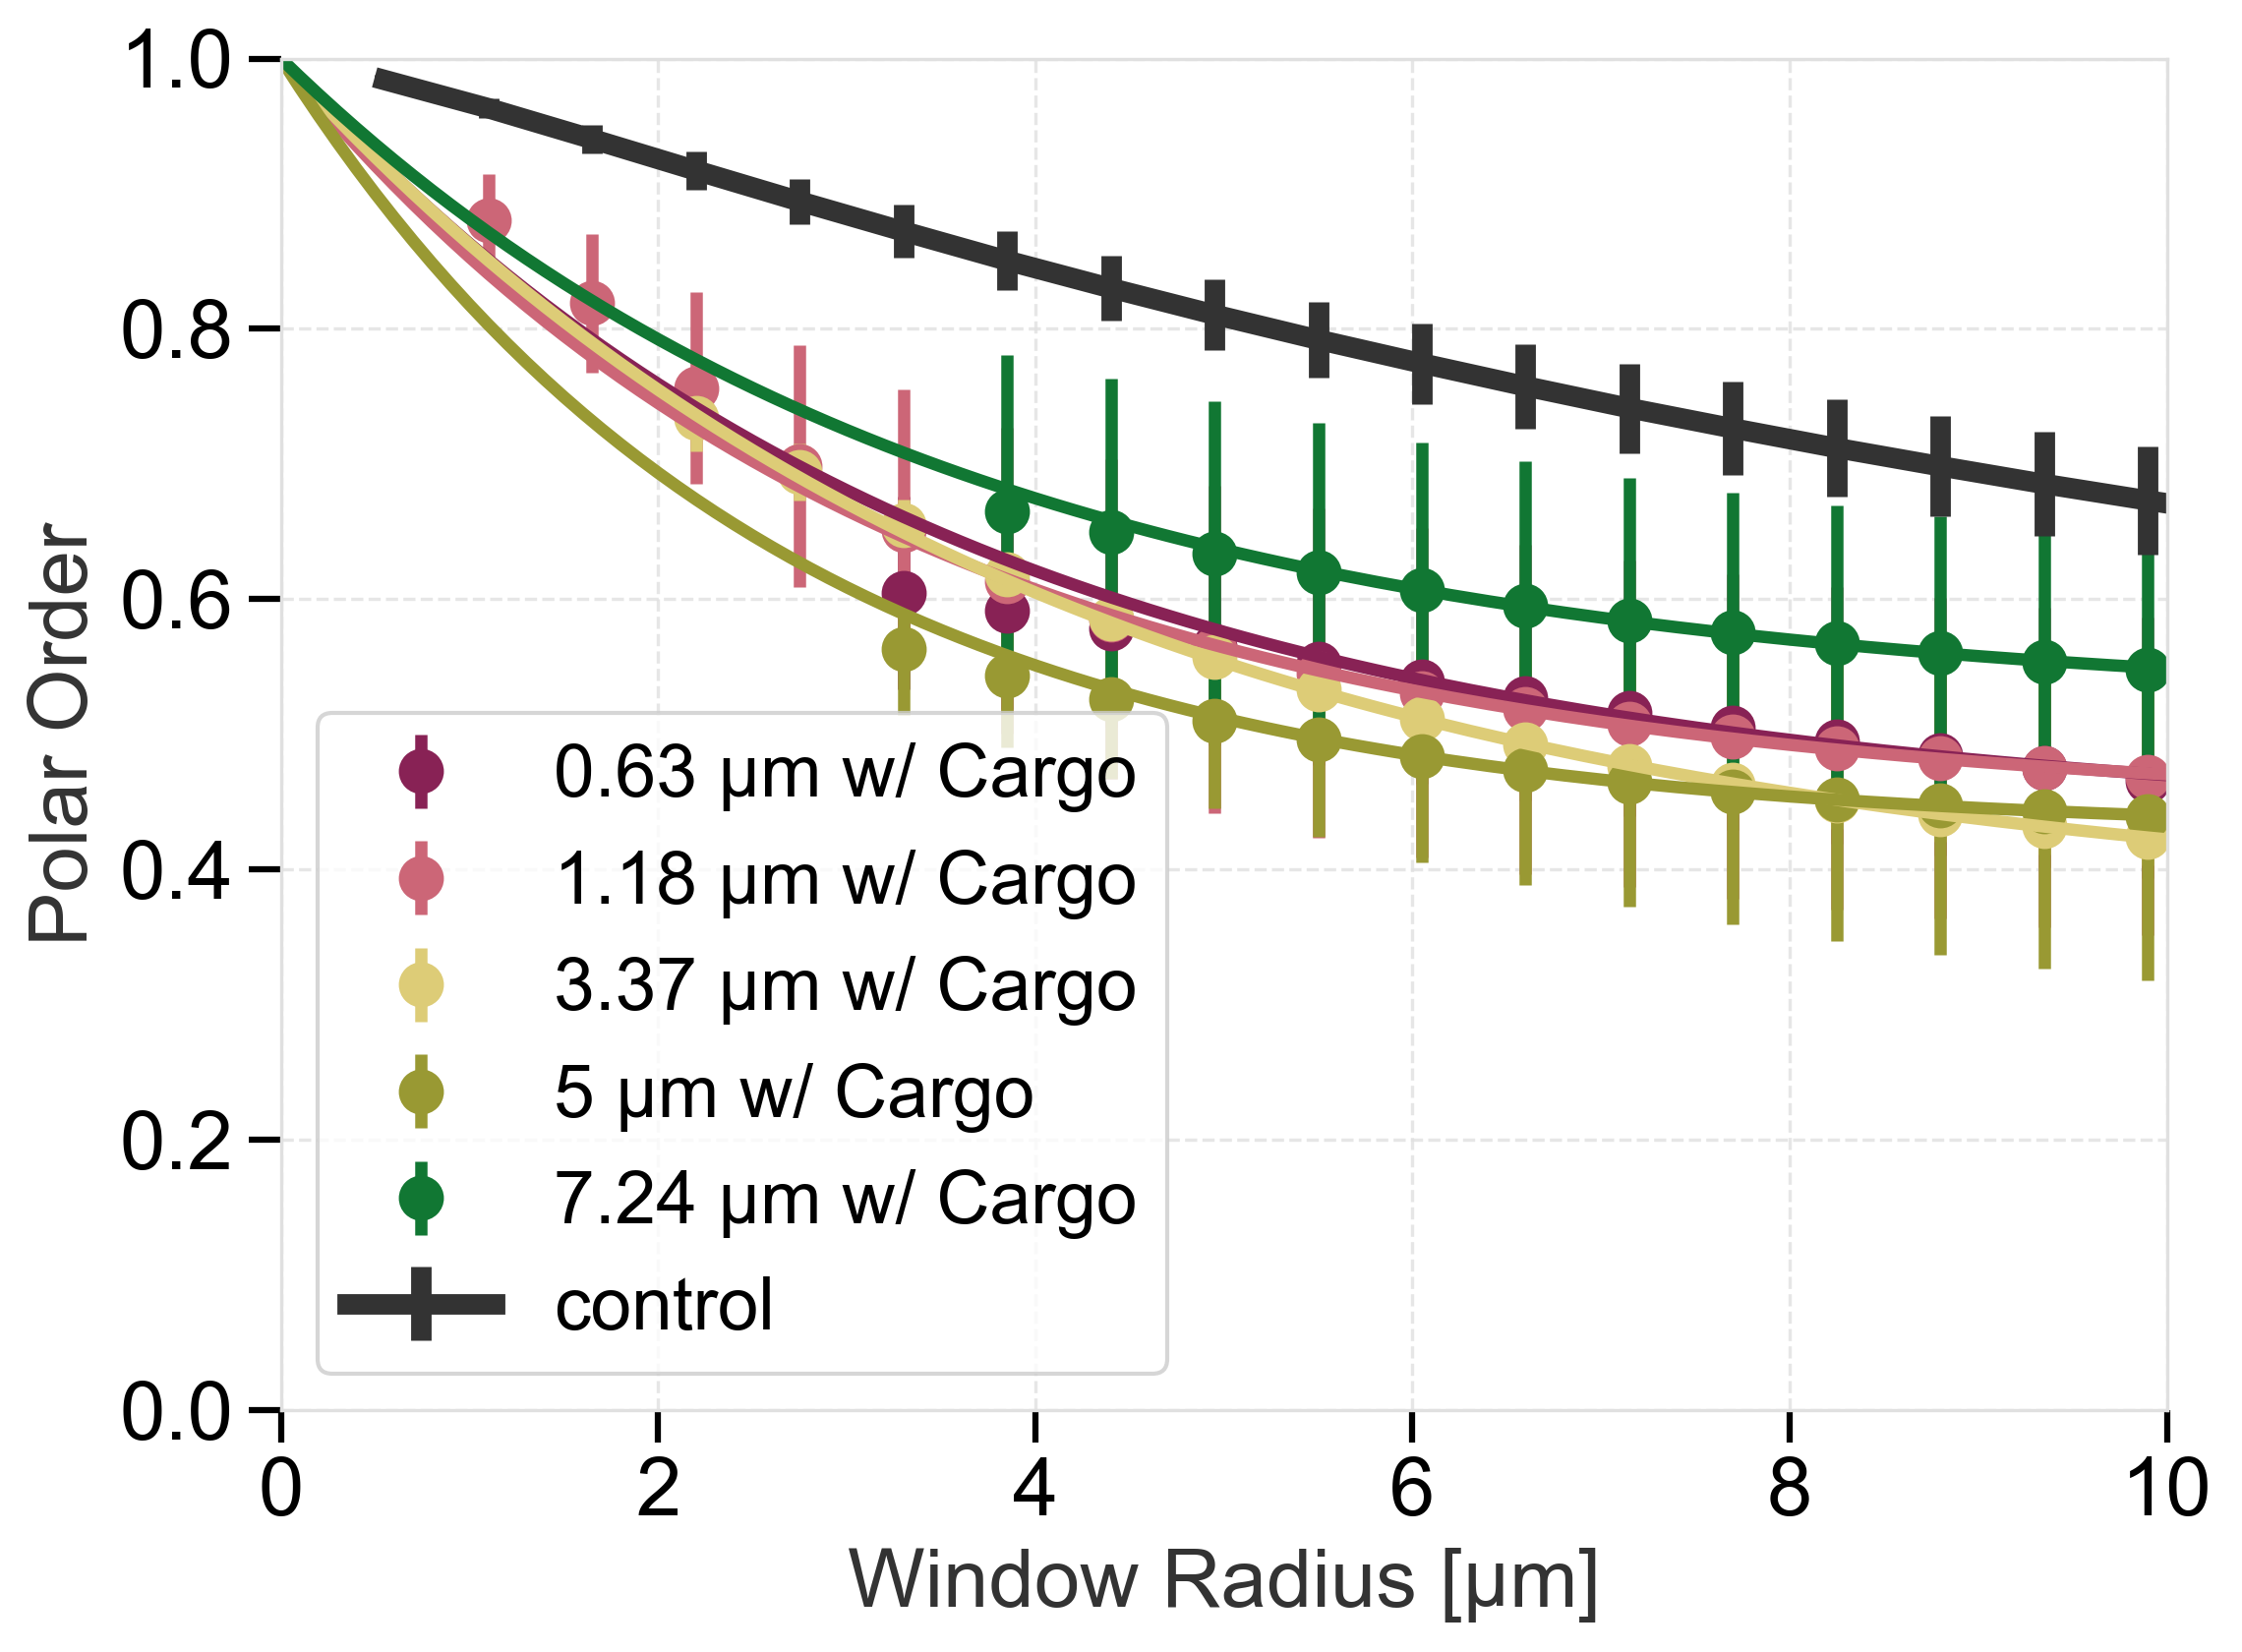

In [57]:
fig, ax = plt.subplots()

_, _, _, popt_p06, _ =plot_polar(df_p06, ax=ax, label='0.63 \u03bcm w/ Cargo', marker='o', color=style_colors[0], fitting = True, min_window=5, max_window=10)
_, _, _, popt_p1, _ =plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', color=style_colors[1], fitting = True, min_window=5, max_window=10)
_, _, _, popt_p3, _ =plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', color=style_colors[2], fitting = True, min_window=5, max_window=10)
_, _, _, popt_p5, _ =plot_polar(df_p5, ax=ax, label='5 \u03bcm w/ Cargo', marker='o', color=style_colors[3], fitting = True, min_window=5, max_window=10)
_, _, _, popt_p7, _ =plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', color=style_colors[4], fitting = True, min_window=5, max_window=10)

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5)

popt_list = [popt_p06[0], popt_p1[0], popt_p3[0], popt_p5[0], popt_p7[0]]

for i in popt_list:
    print('xi', i)

ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_w_zoom.svg")

(0.0, 1.0)

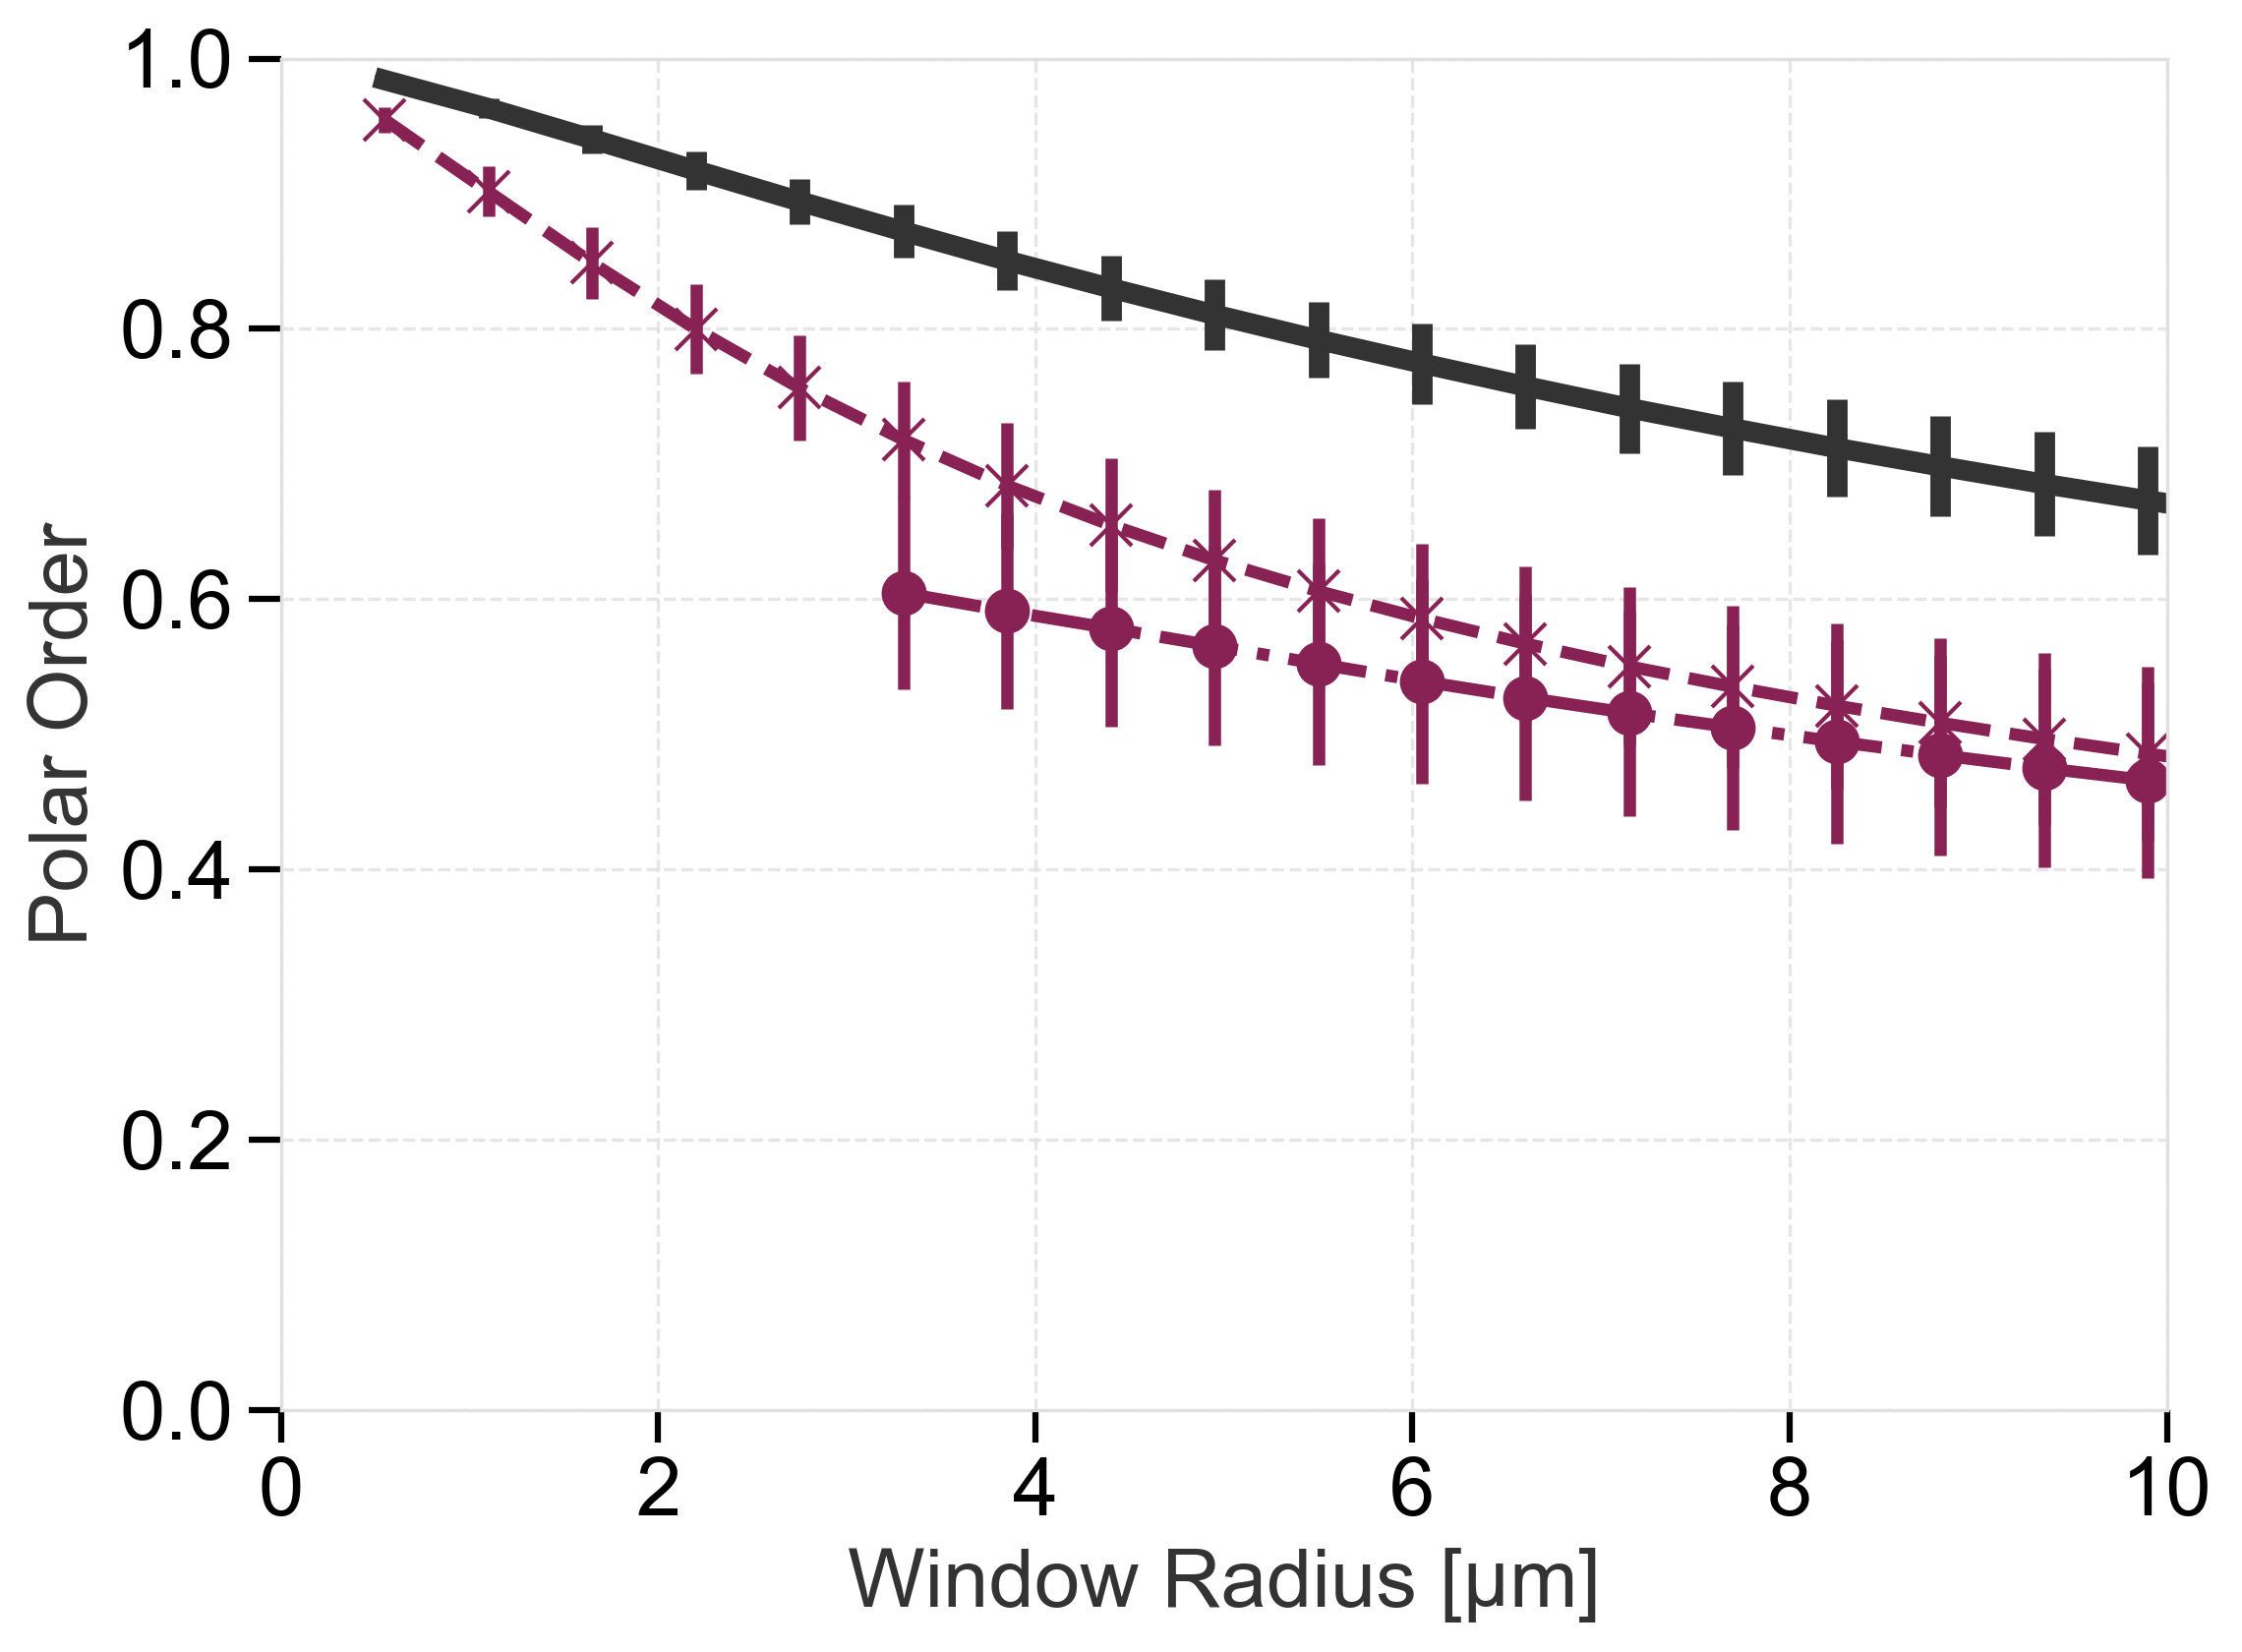

In [48]:
fig, ax = plt.subplots()
plot_polar(df_p06, ax=ax, label='0.63 \u03bcm w/ Cargo', marker='o', linestyle='-.', color=style_colors[0])
plot_polar(df_bg06, ax=ax, label='0.63 \u03bcm w/o Cargo', marker='x', linestyle='--', color=style_colors[0])

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5)

ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

#fig.savefig(root / "figure" / "local_polar_zoom_06um.svg")

3.2252932250908466


(0.0, 1.0)

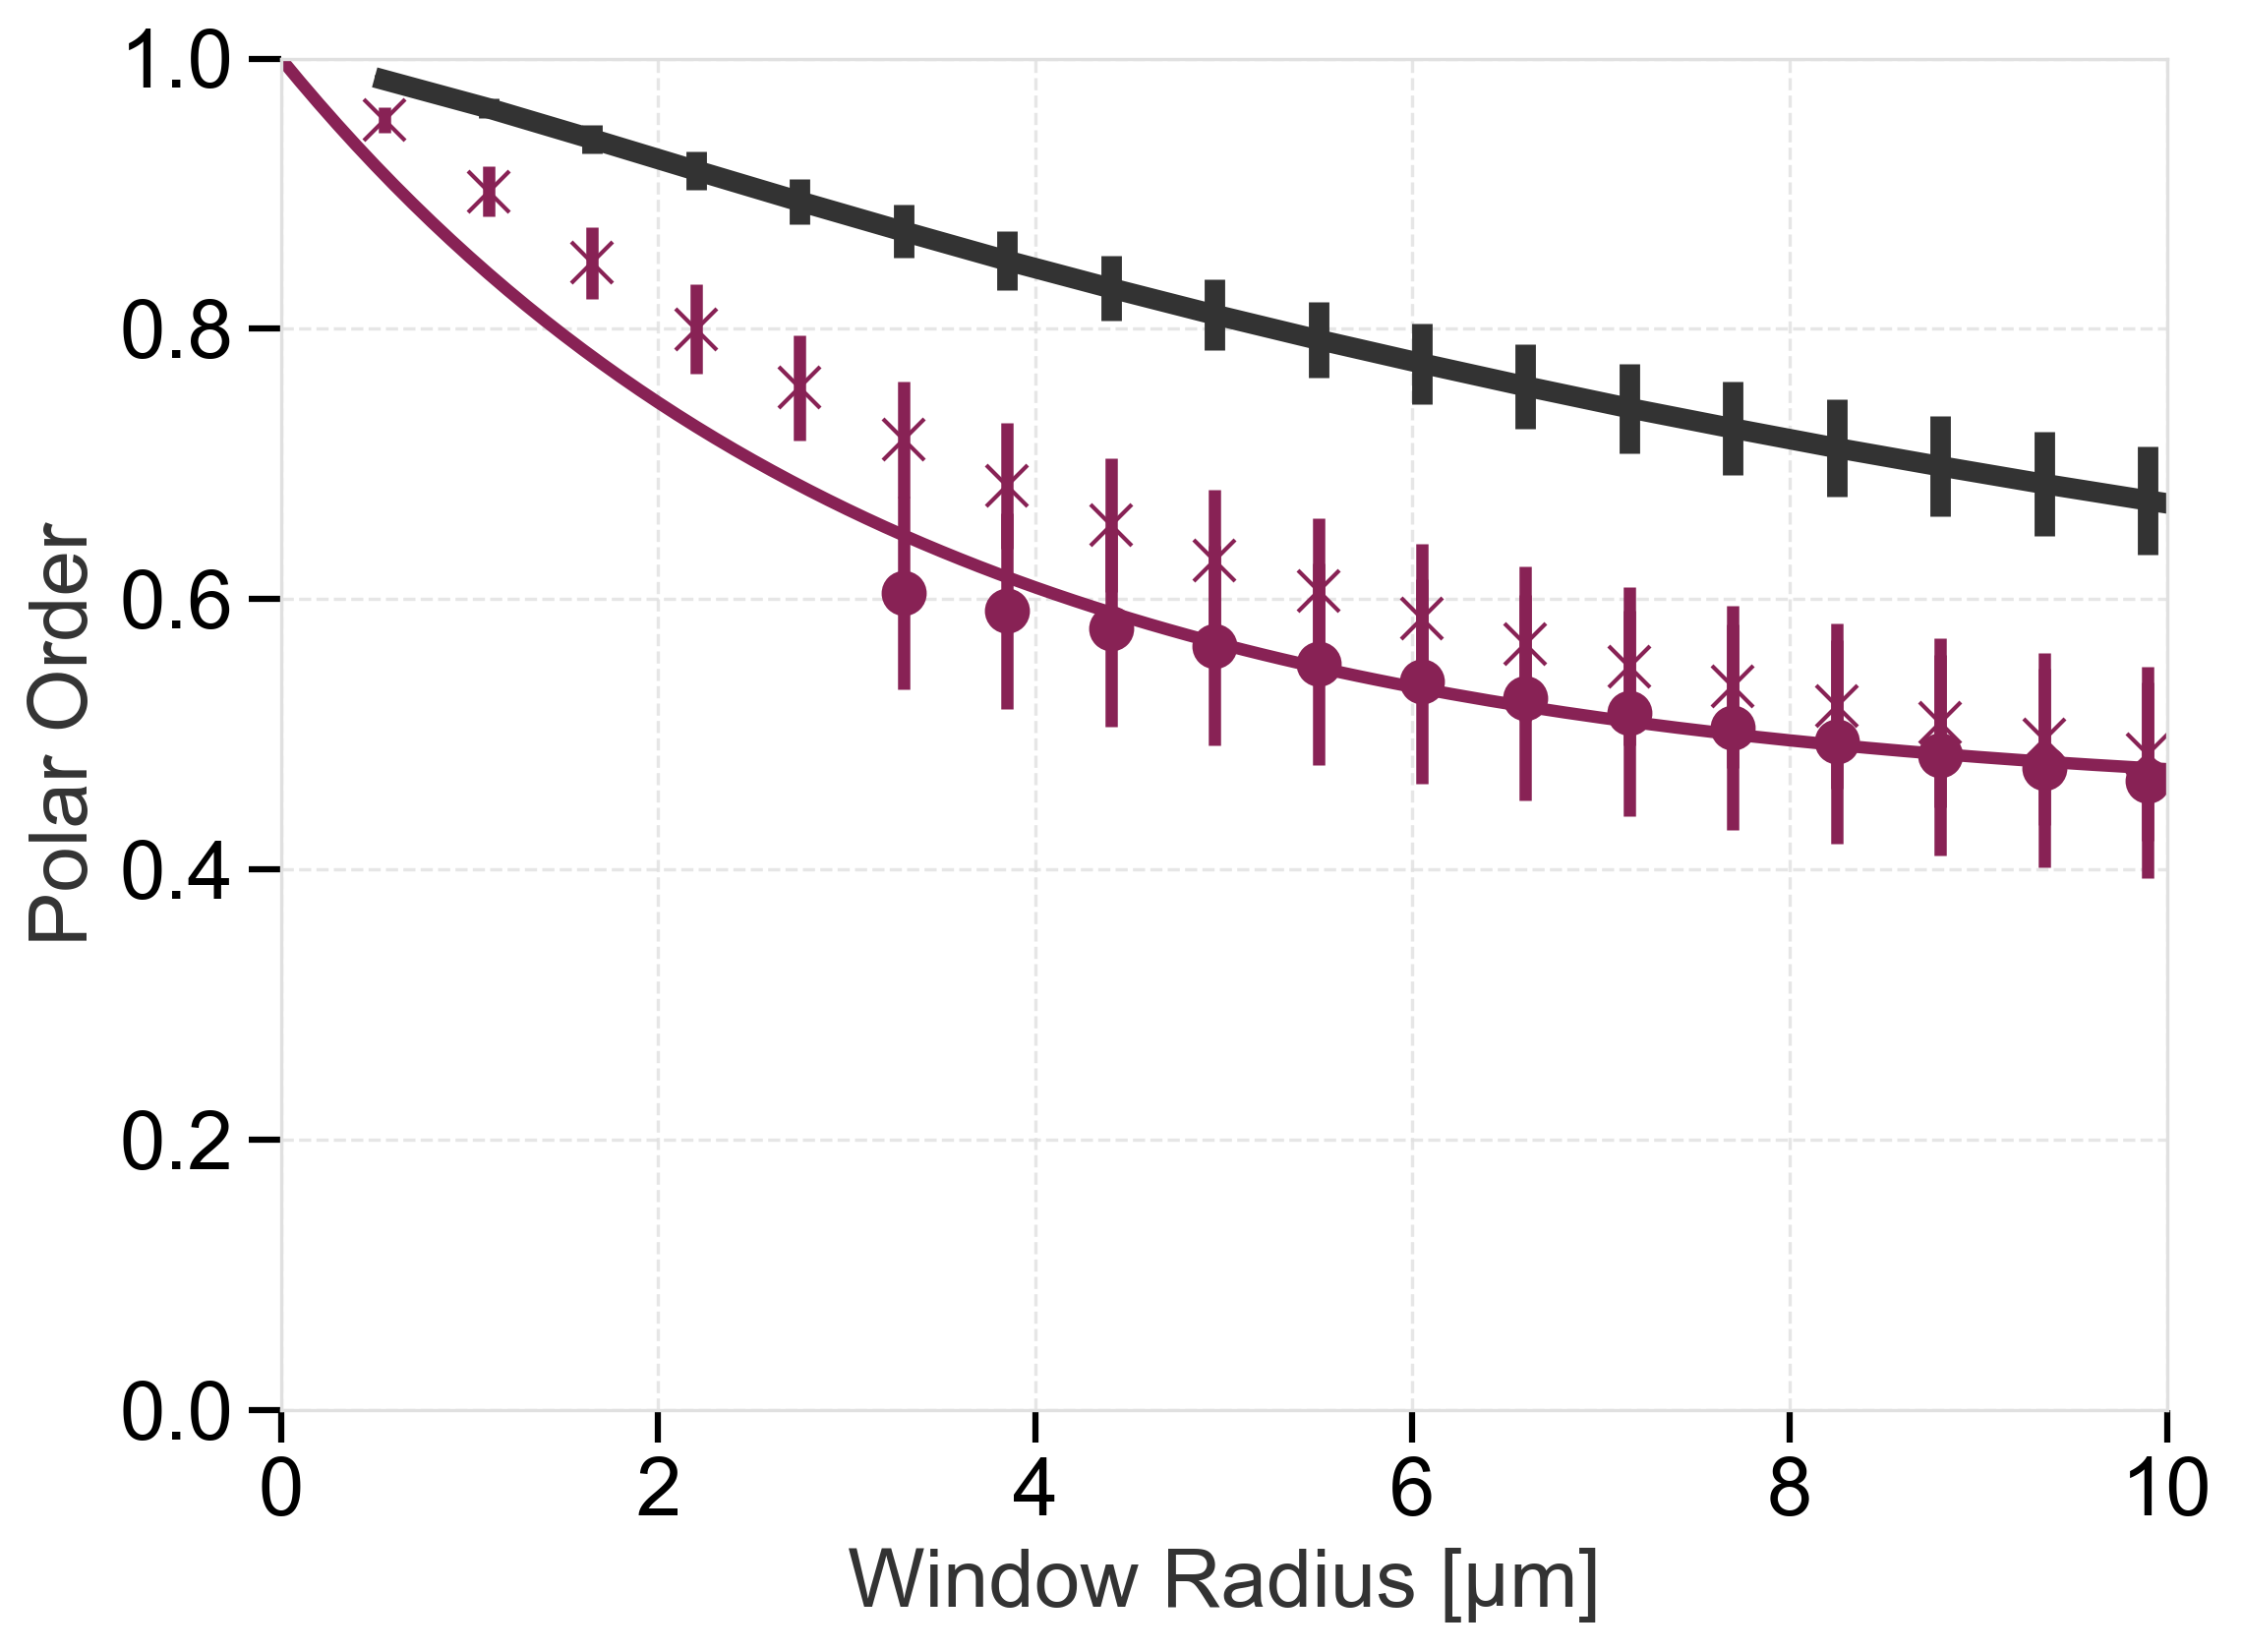

In [50]:
fig, ax = plt.subplots()
_, _, _, popt_p06, _ =plot_polar(df_p06, ax=ax, label='0.63 \u03bcm w/ Cargo', marker='o', color=style_colors[0], fitting = True, min_window=4, max_window=10)
plot_polar(df_bg06, ax=ax, label='0.63 \u03bcm w/o Cargo', marker='x', color=style_colors[0])

plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5)

print(popt_p06[0])

ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

#fig.savefig(root / "figure" / "local_polar_zoom_06um.svg")

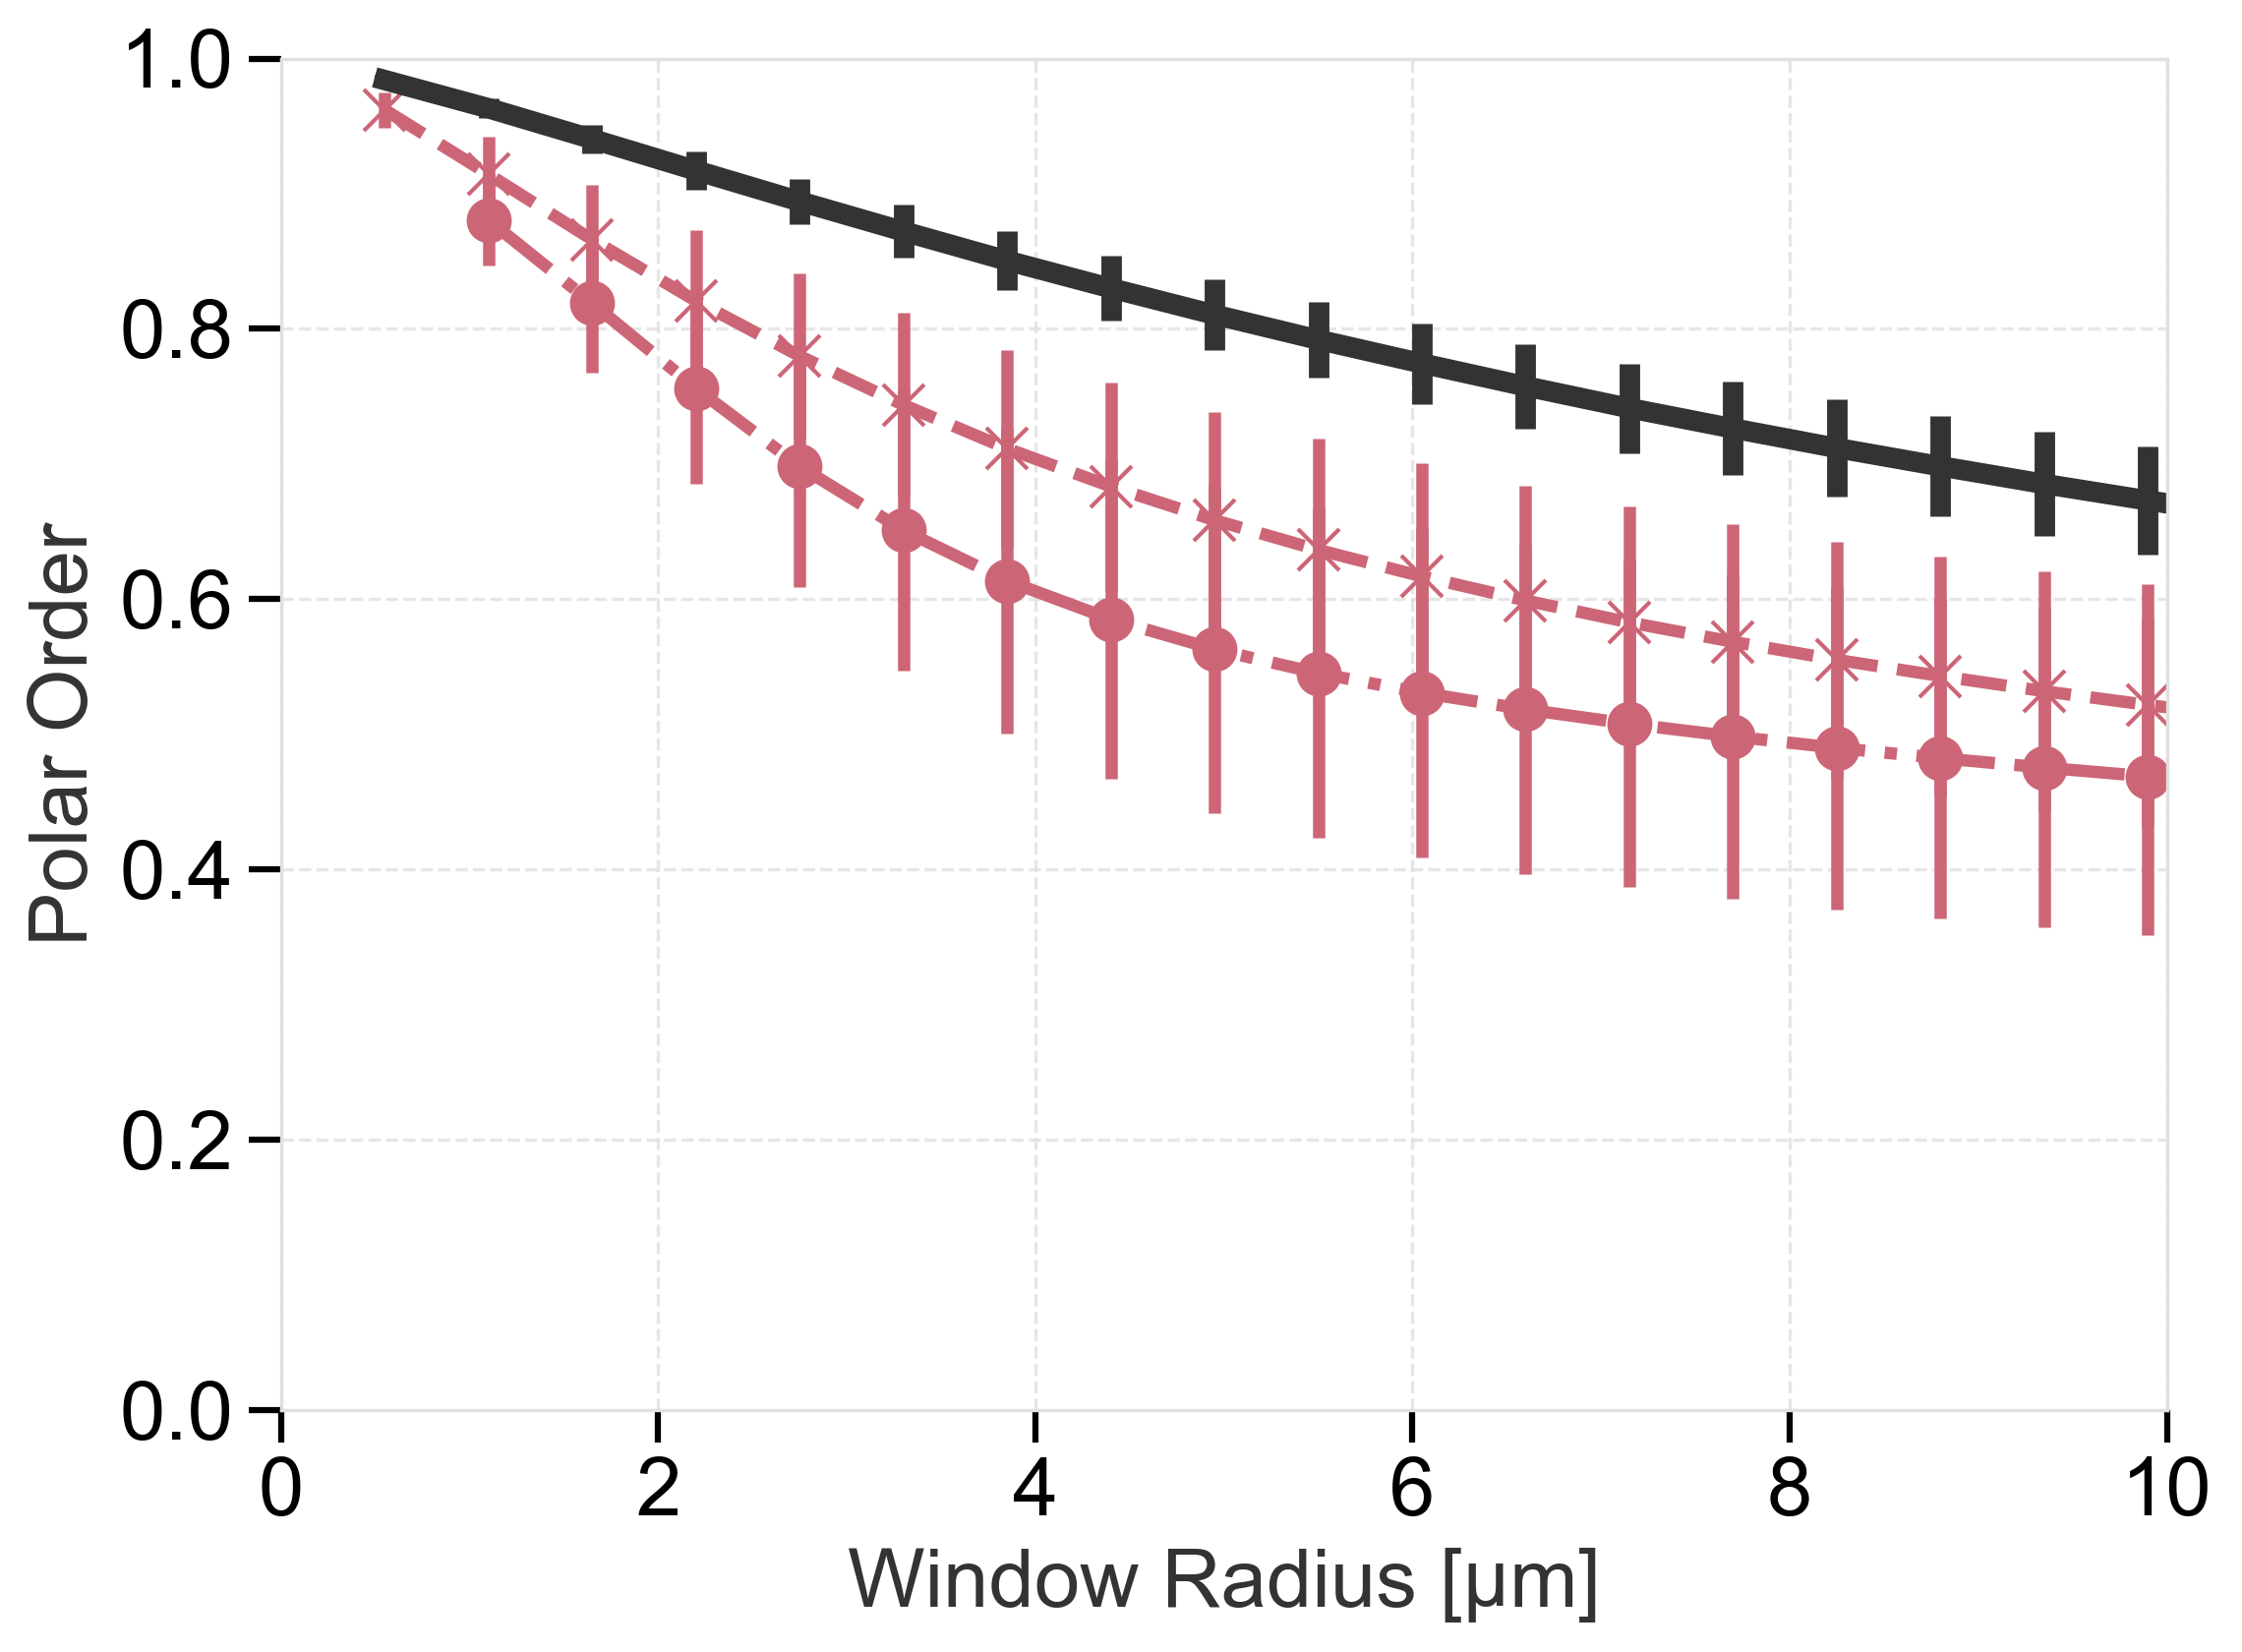

In [15]:
fig, ax = plt.subplots()
plot_polar(df_p1, ax=ax, label='1.18 \u03bcm w/ Cargo', marker='o', linestyle='-.', color=style_colors[1])
plot_polar(df_bg1, ax=ax, label='1.18 \u03bcm w/o Cargo', marker='x', linestyle='--', color=style_colors[1])


plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5)

ax.set_xlabel('Window Radius [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom_1um.svg")

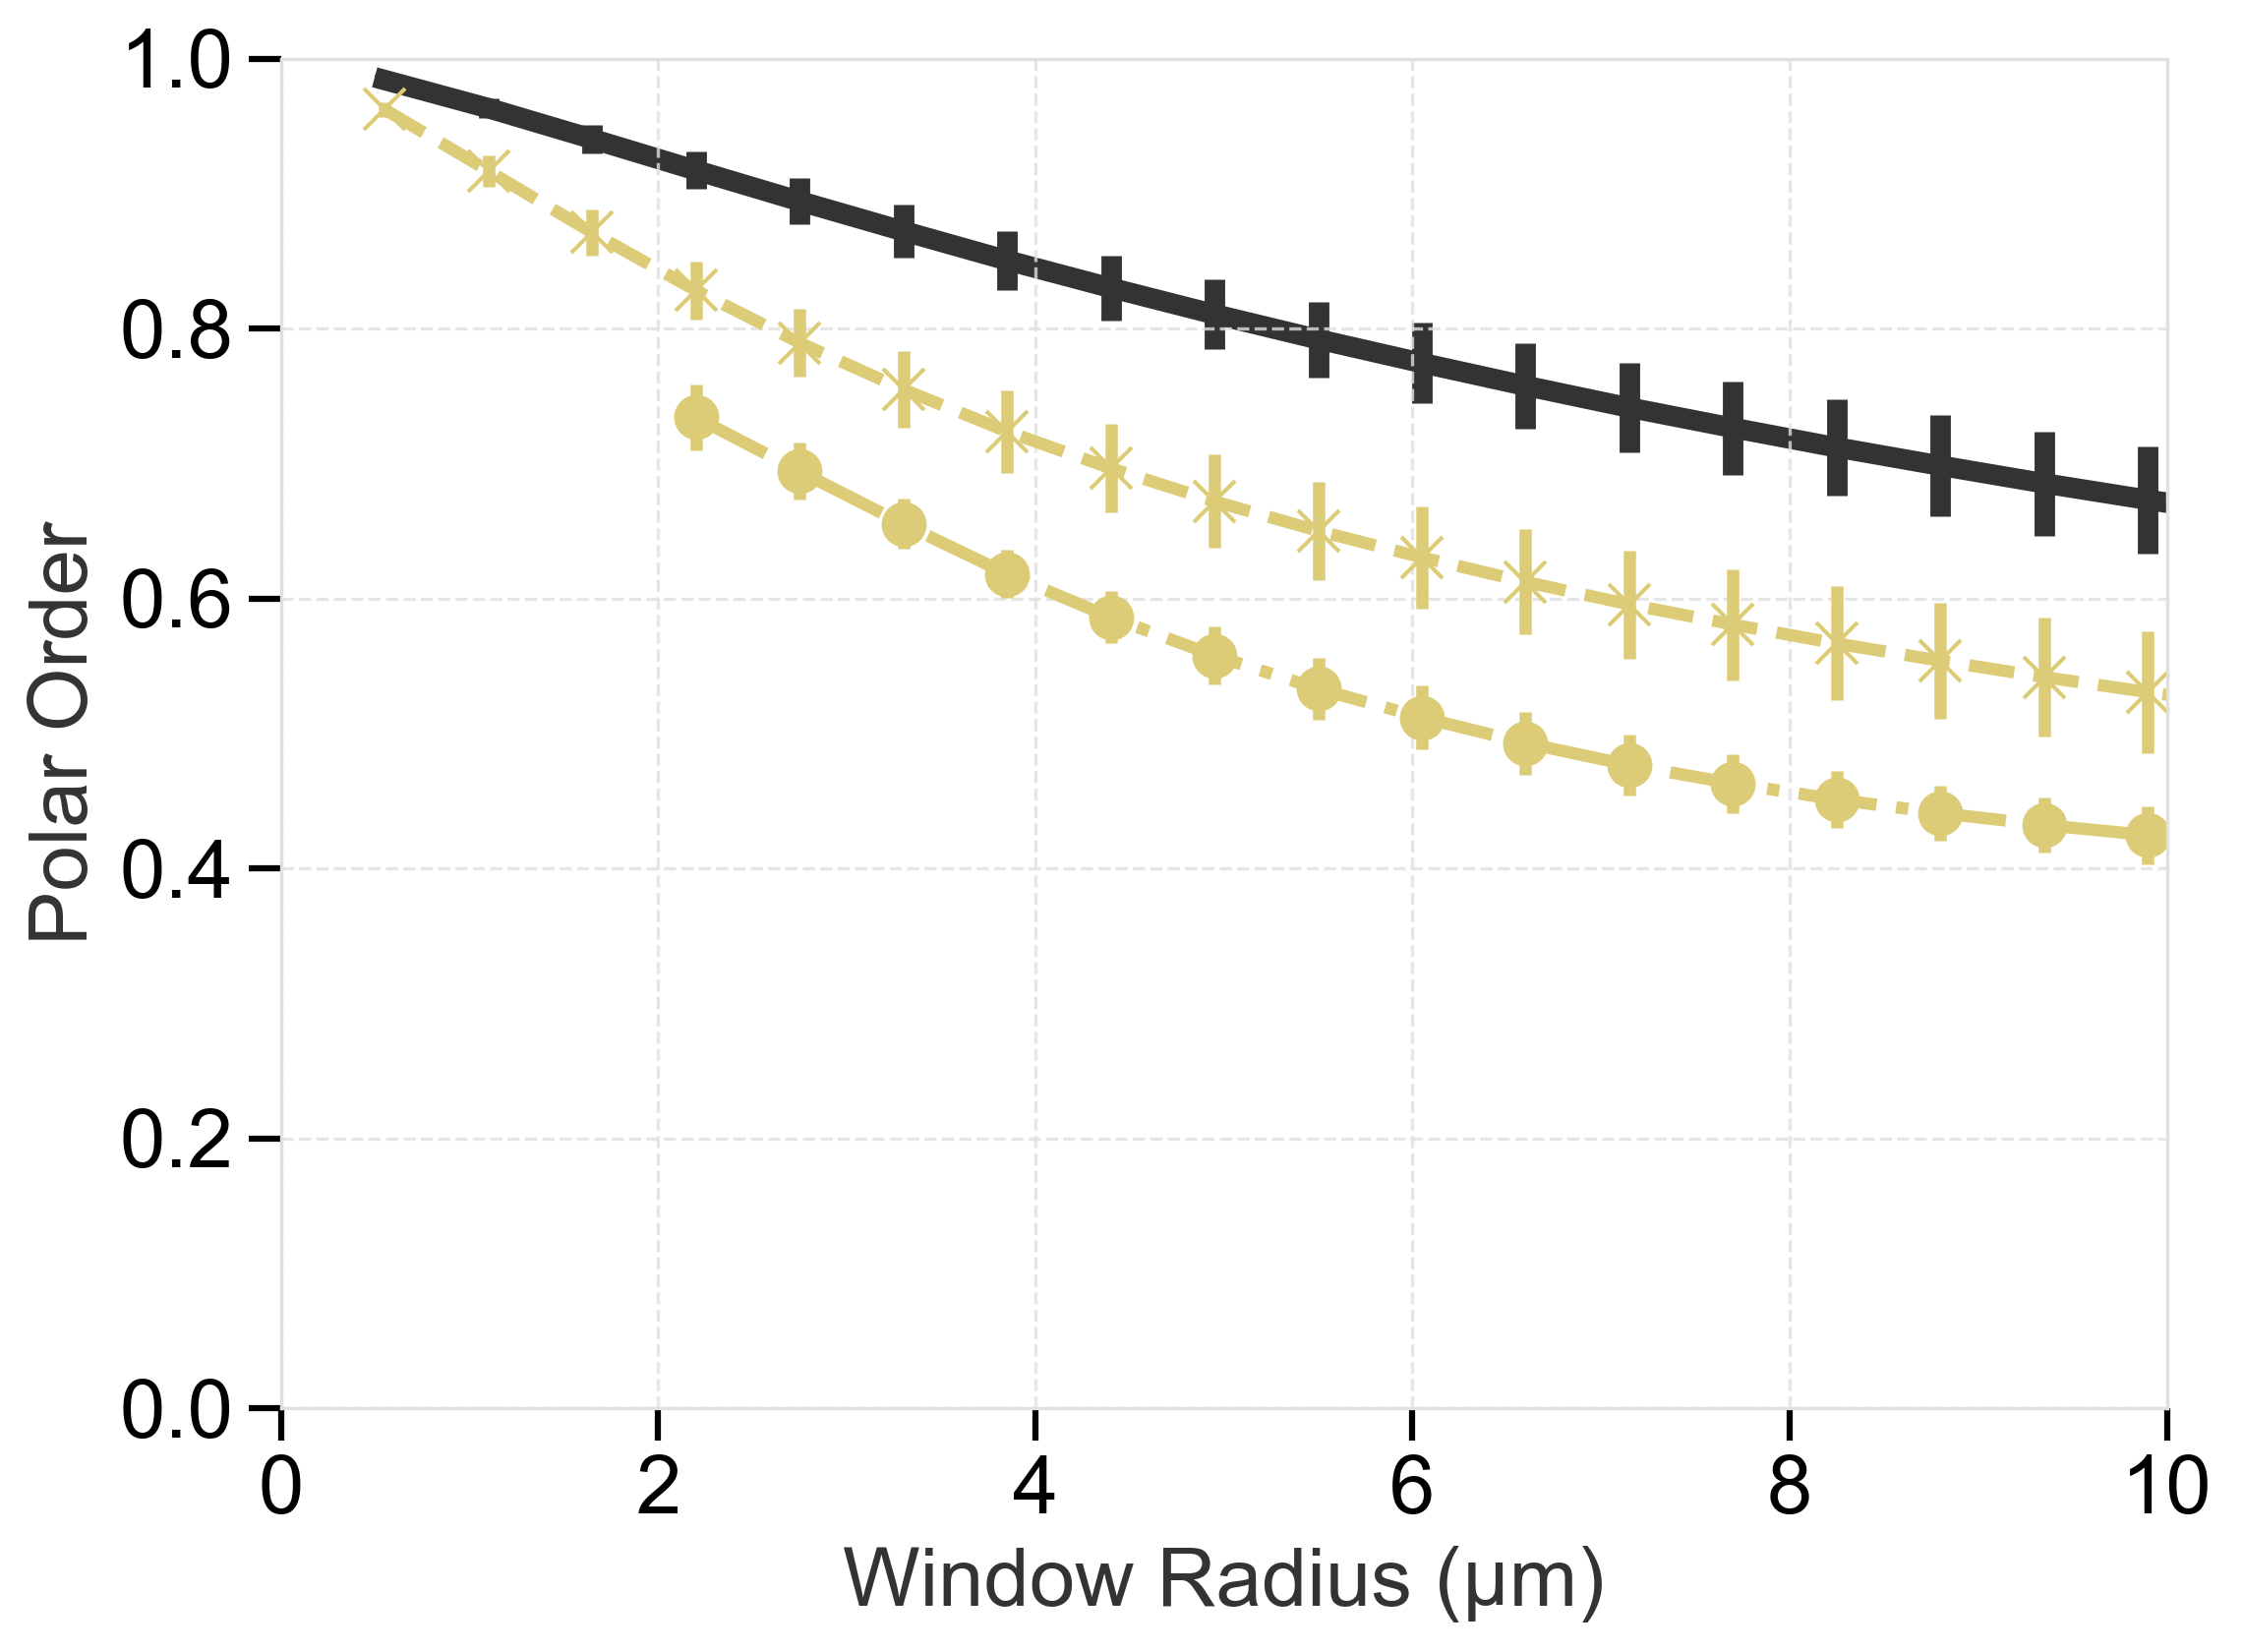

In [16]:
fig, ax = plt.subplots()
plot_polar(df_p3, ax=ax, label='3.37 \u03bcm w/ Cargo', marker='o', linestyle='-.', color=style_colors[2])
plot_polar(df_bg3, ax=ax, label='3.37 \u03bcm w/o Cargo', marker='x', linestyle='--', color=style_colors[2])


plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5, zorder=-1)

ax.set_xlabel('Window Radius (\u03bcm)')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom_3um.svg")

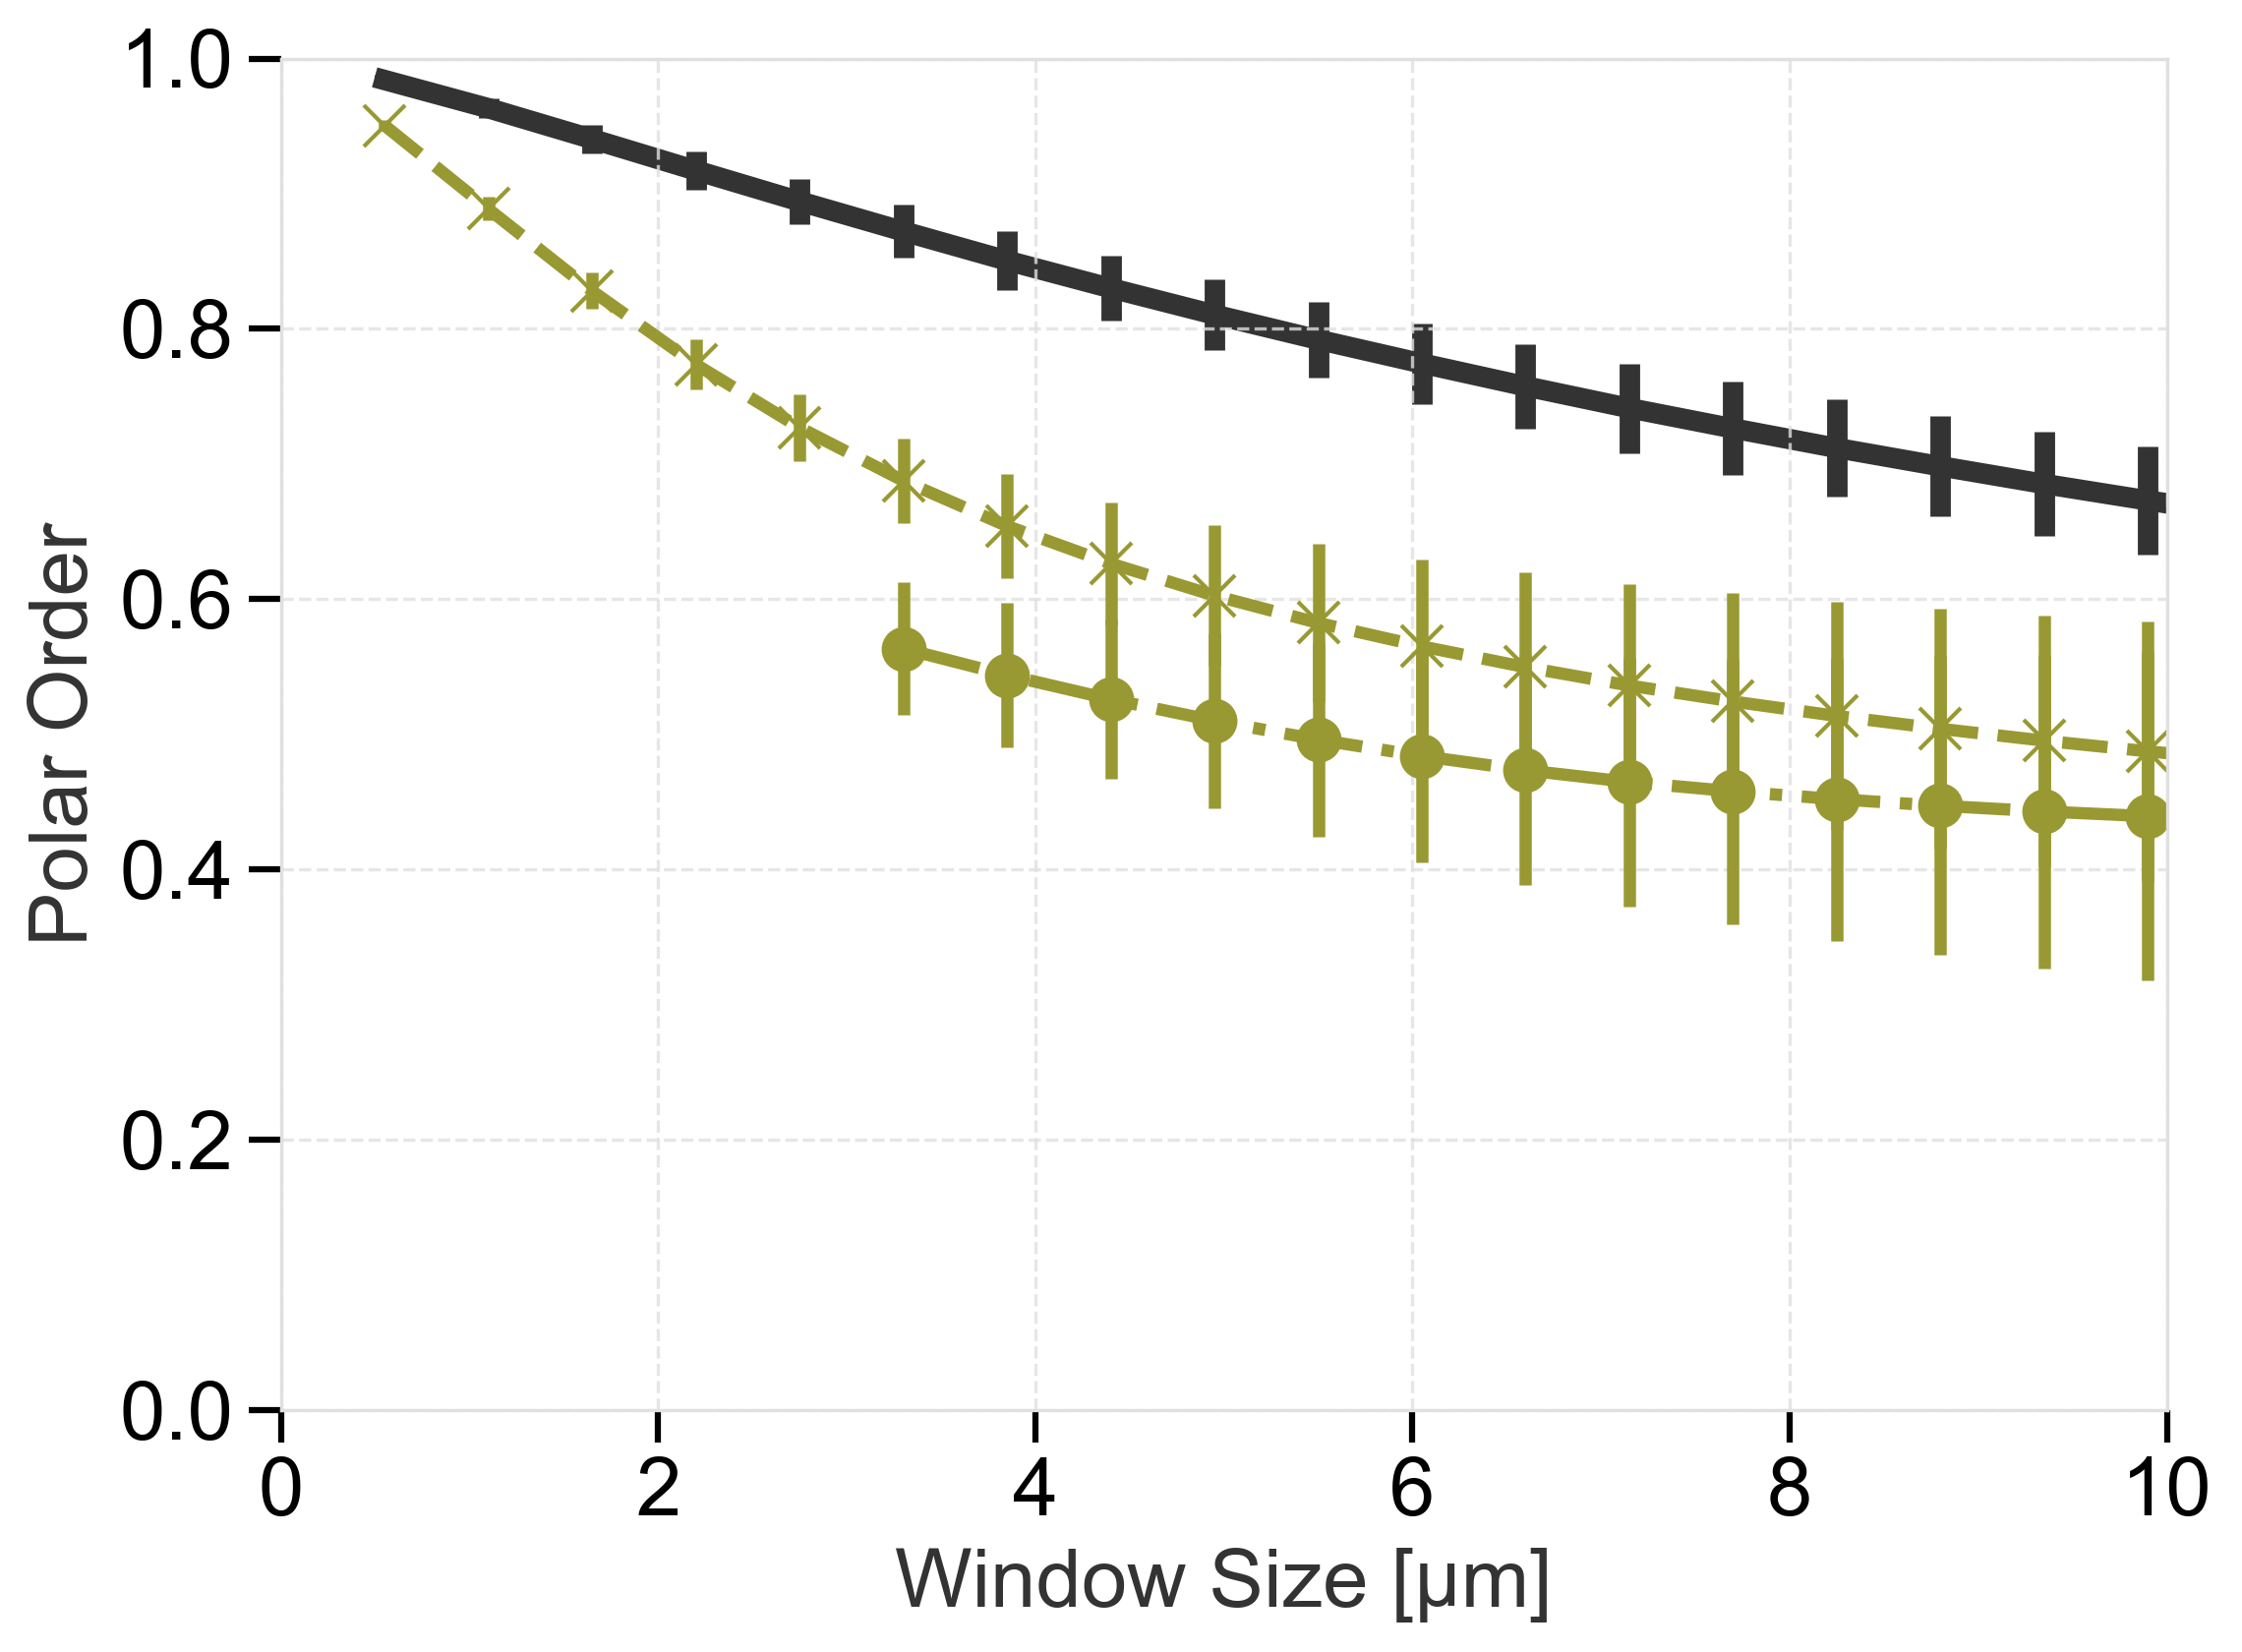

In [17]:
fig, ax = plt.subplots()
plot_polar(df_p5, ax=ax, label='5.00 \u03bcm w/ Cargo', marker='o', linestyle='-.', color=style_colors[3])
plot_polar(df_bg5, ax=ax, label='5.00 \u03bcm w/o Cargo', marker='x', linestyle='--', color=style_colors[3])


plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5, zorder=-1)

ax.set_xlabel('Window Size [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom_5um.svg")

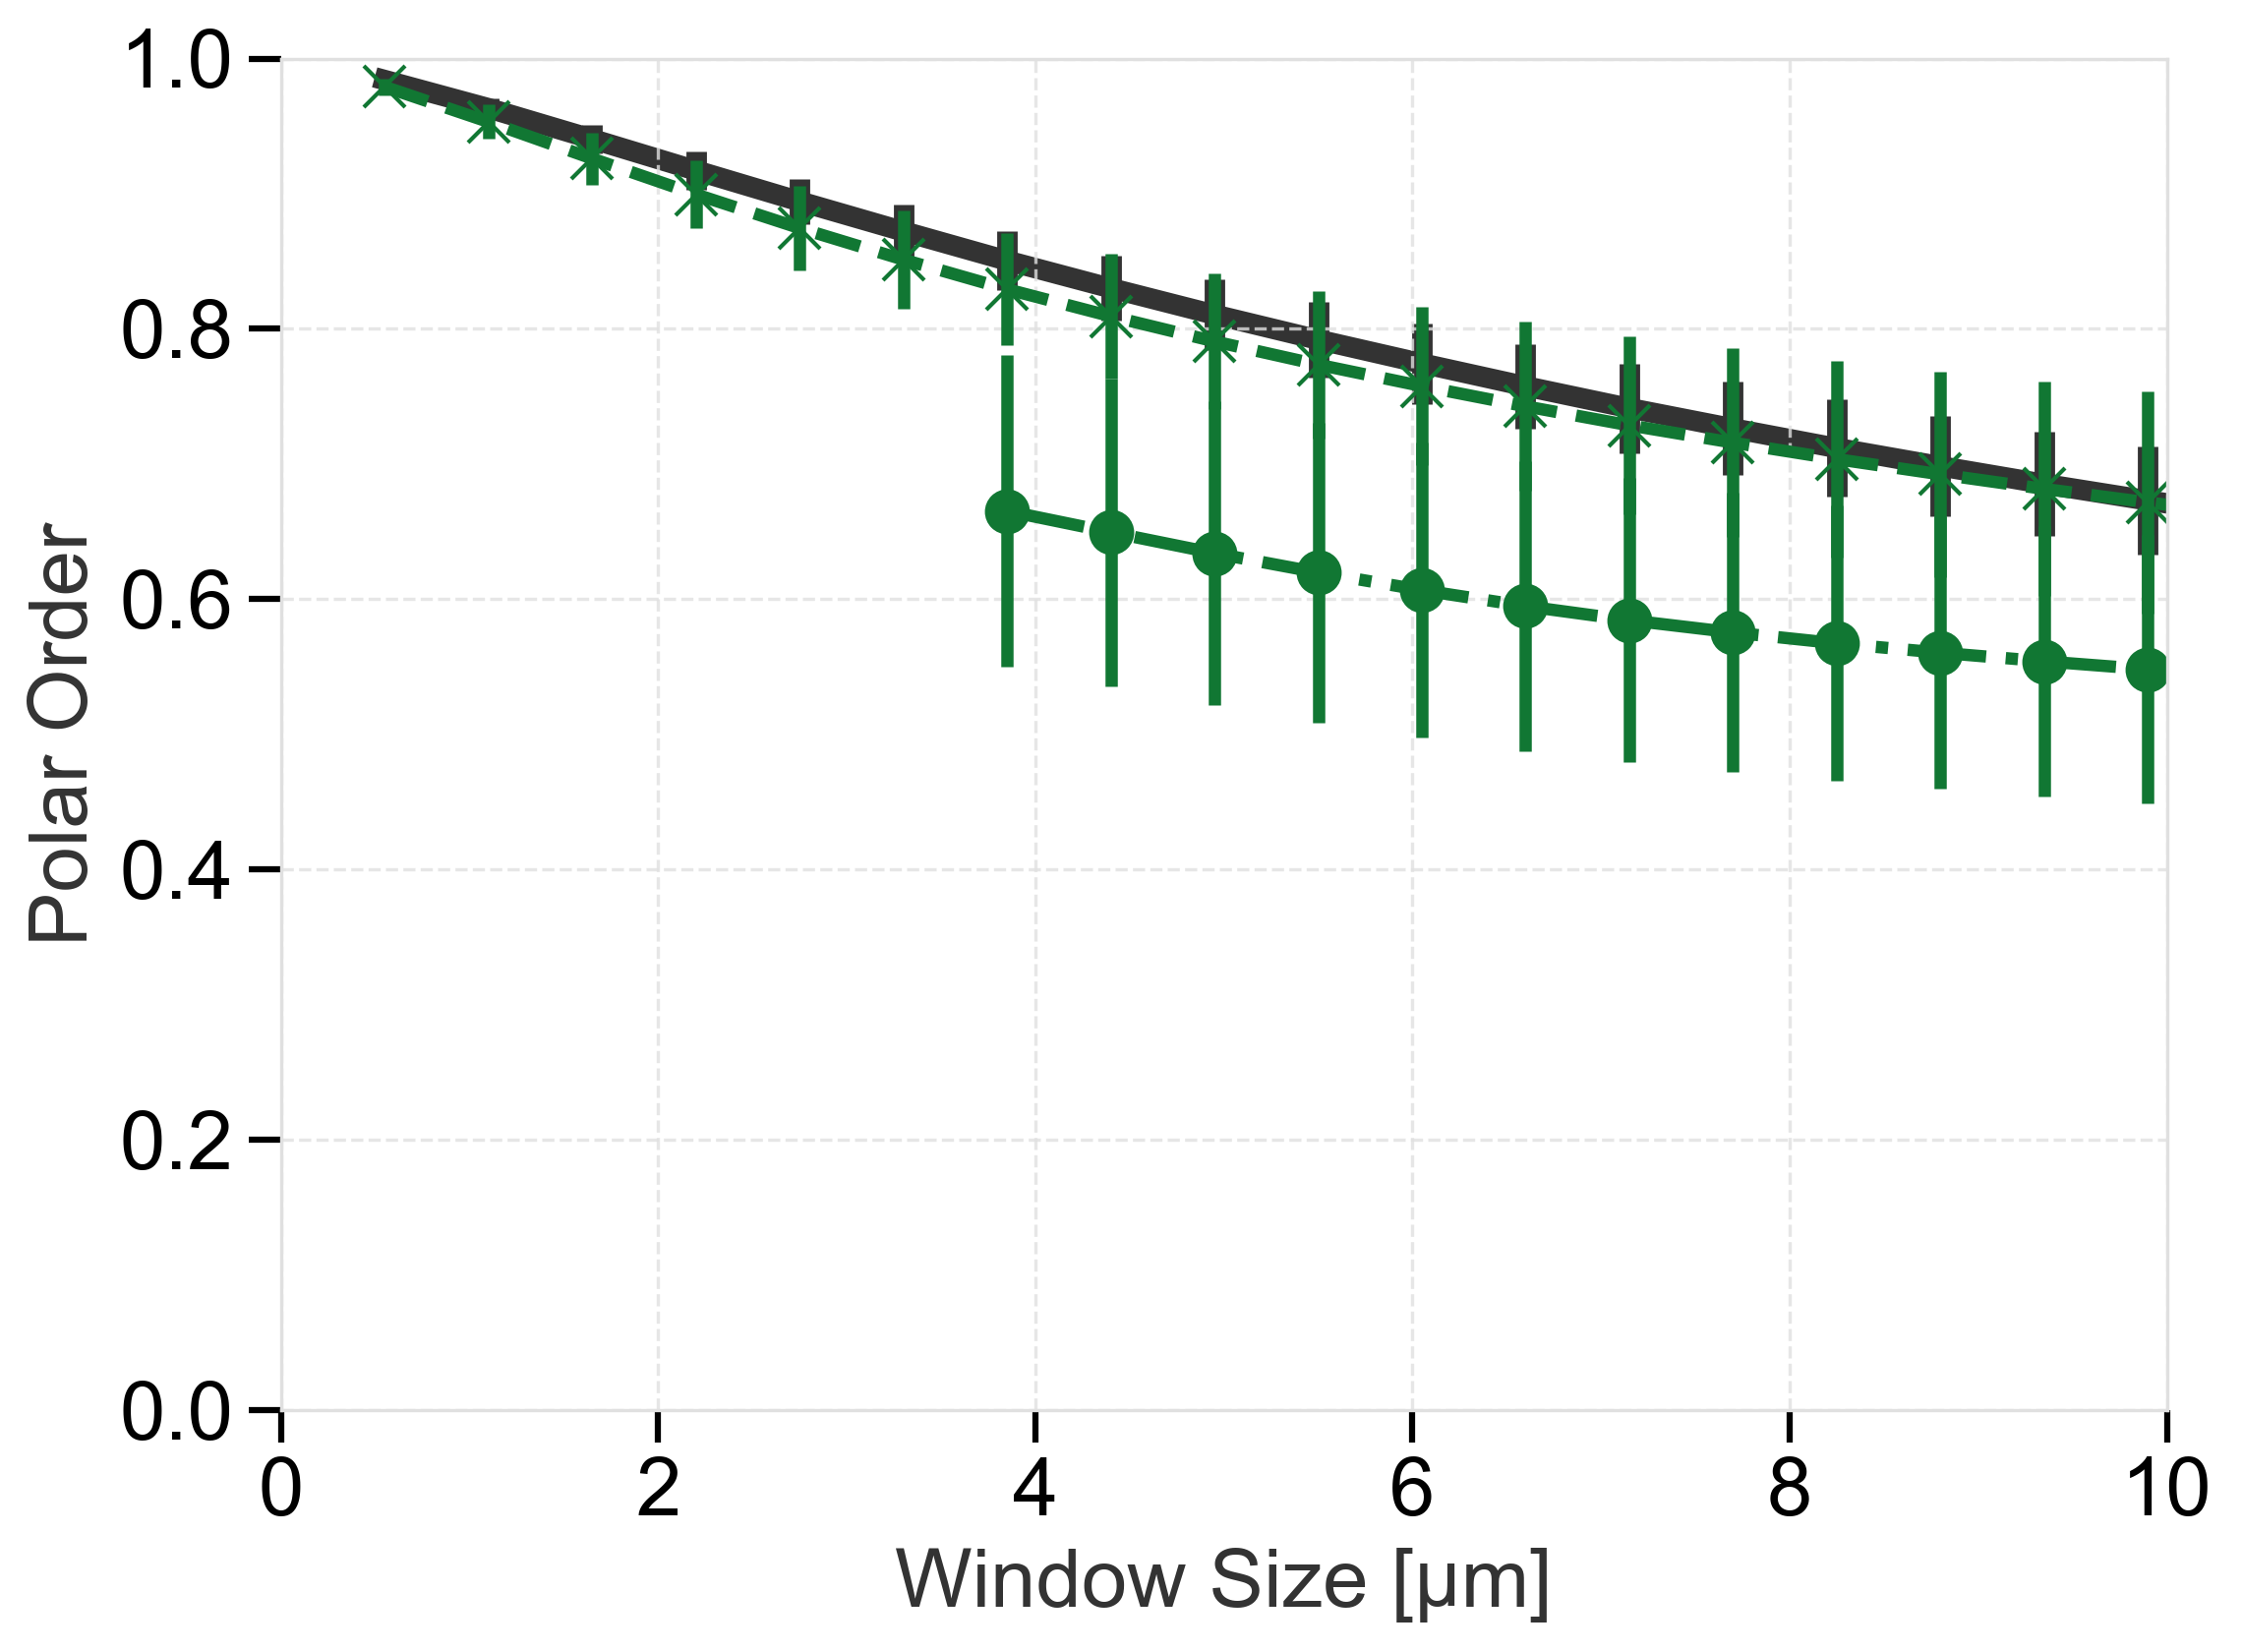

In [18]:
fig, ax = plt.subplots()
plot_polar(df_p7, ax=ax, label='7.24 \u03bcm w/ Cargo', marker='o', linestyle='-.', color=style_colors[4])
plot_polar(df_bg7, ax=ax, label='7.24 \u03bcm w/o Cargo', marker='x', linestyle='--', color=style_colors[4])


plot_polar(df_no, ax = ax, label='control', marker=None, linestyle='-', color='#333333', lw = 5, zorder = -1)

ax.set_xlabel('Window Size [\u03bcm]')
ax.set_ylabel('Polar Order')
ax.set_xlim(0,10)
ax.set_ylim(0,1)
#ax.set_title('Polar Order vs Window Size')
#ax.legend()

fig.savefig(root / "figure" / "local_polar_zoom_7um.svg")

xi=14.515397479783344, p0=0.3369954932895978


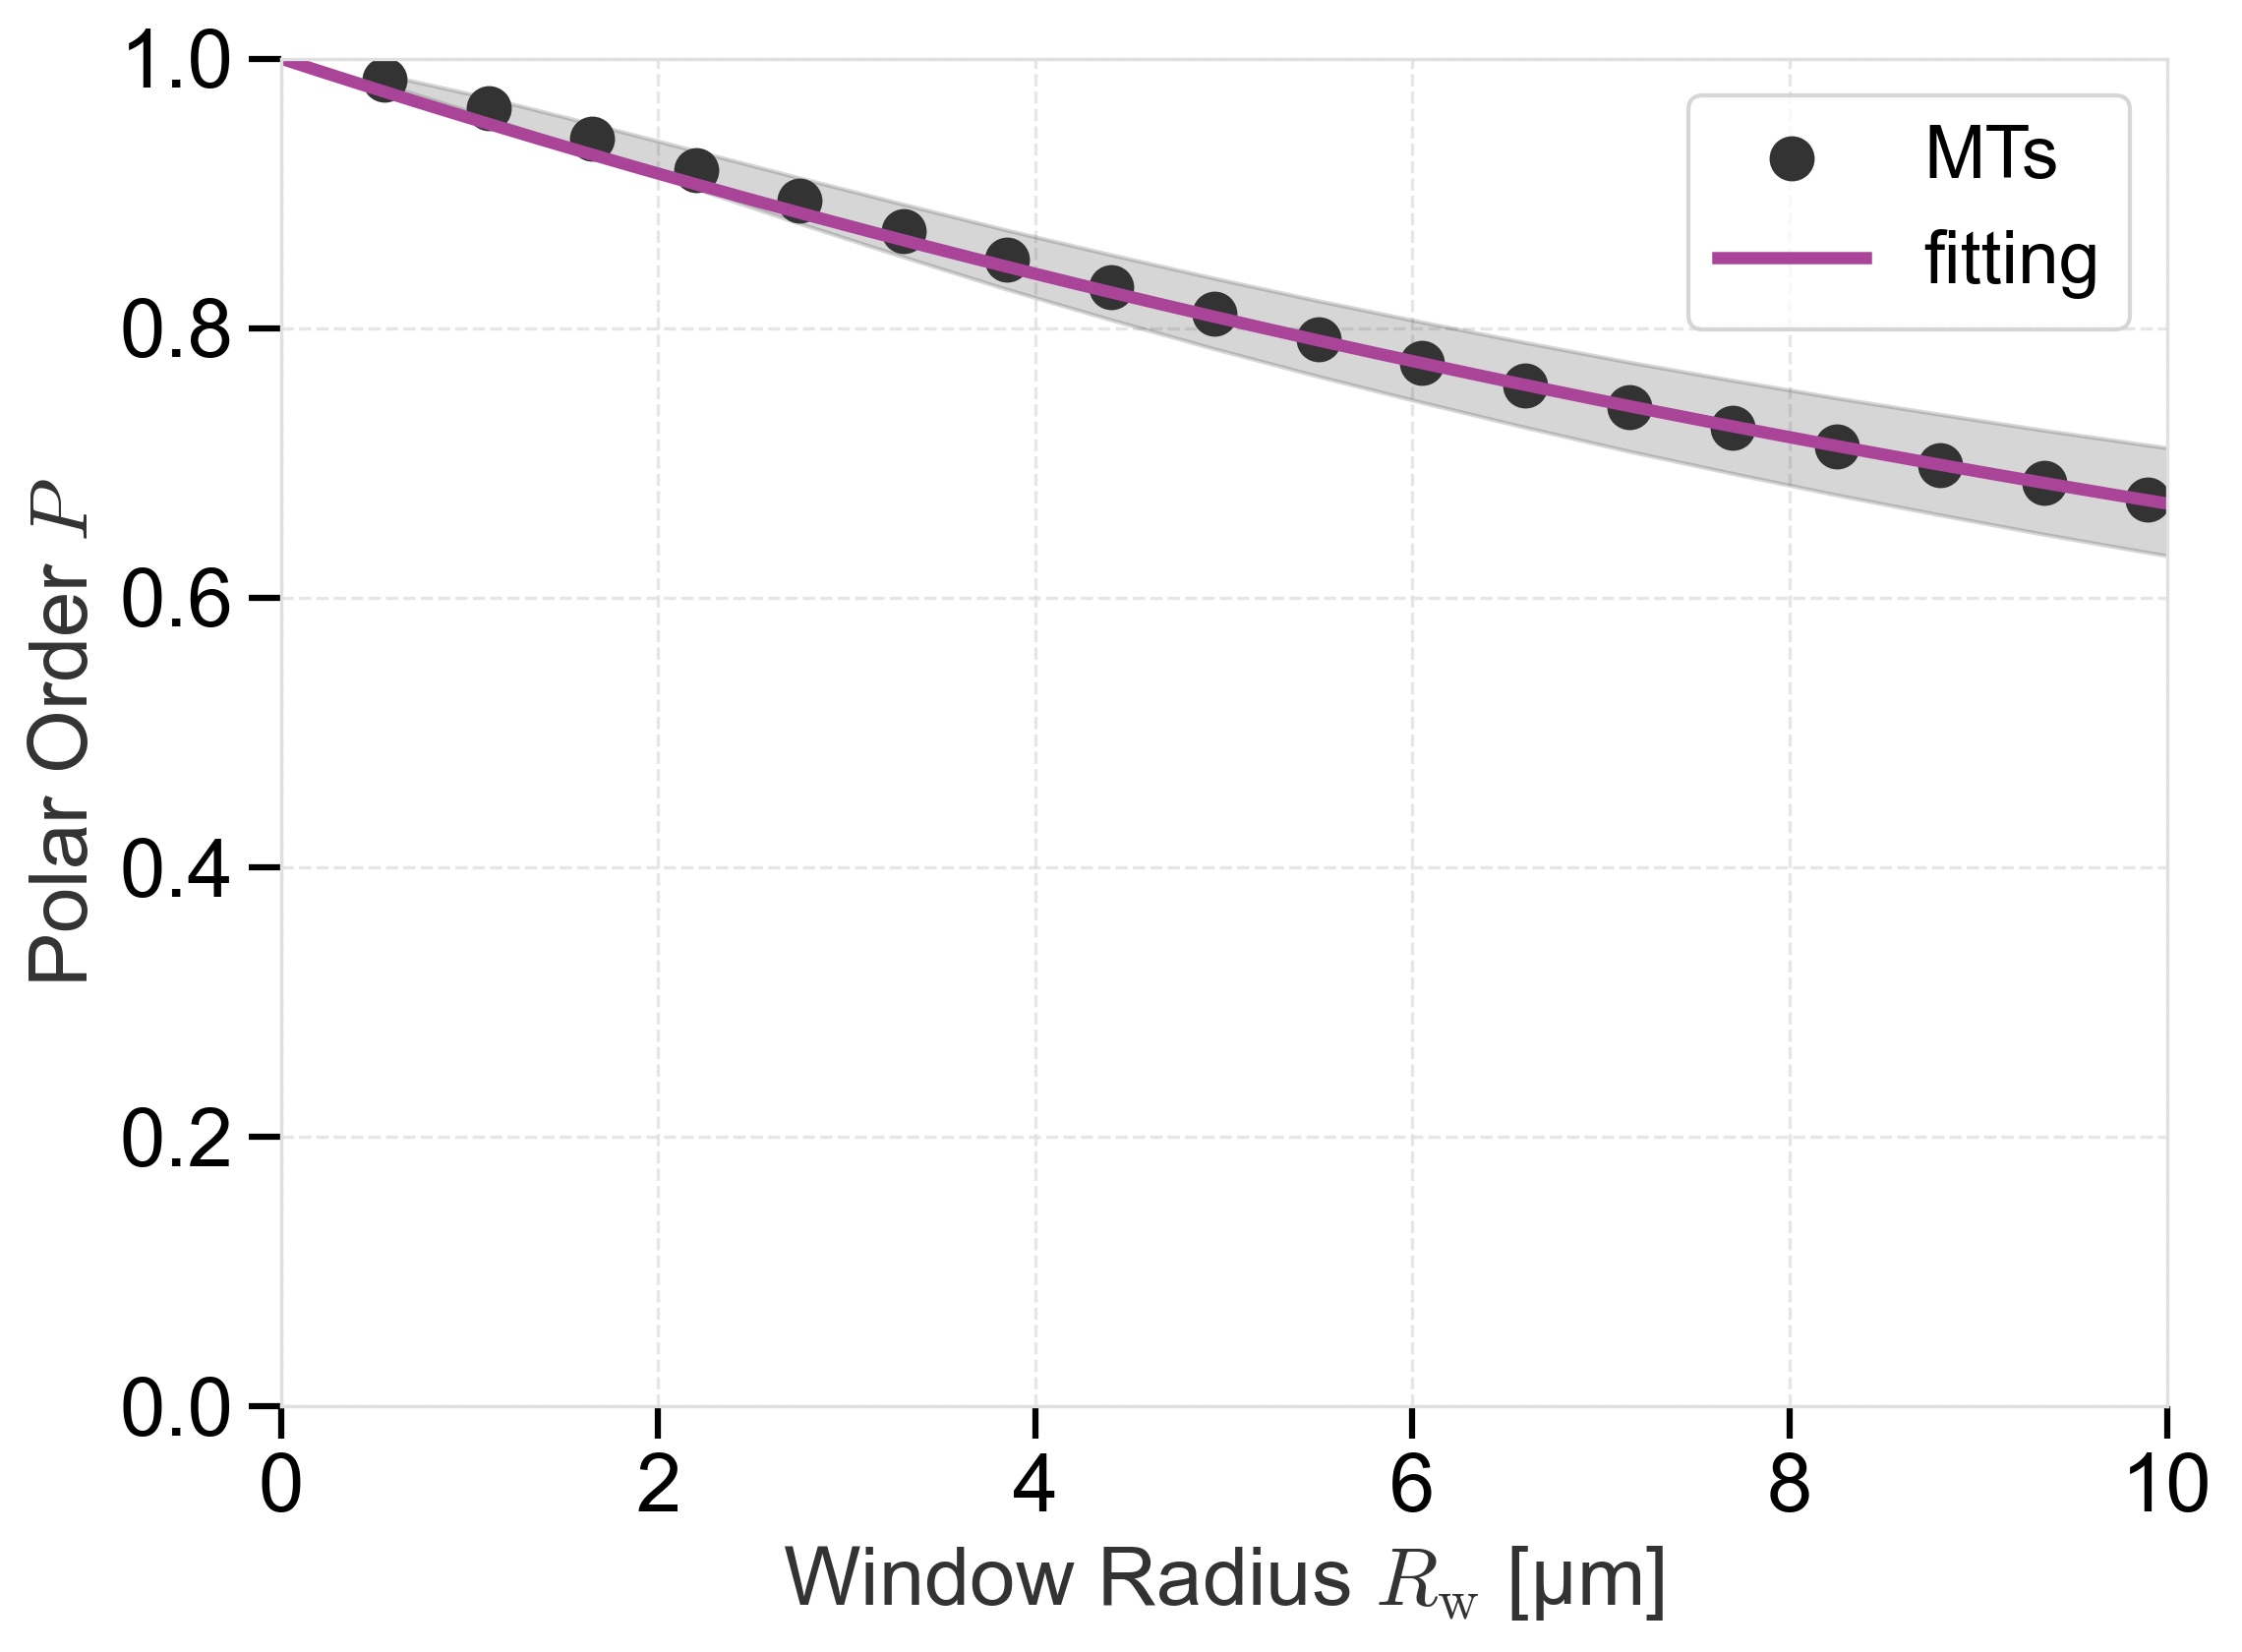

In [60]:
from scipy.optimize import curve_fit

def exp_fit(x, A, xi, y0):
    return A*np.exp(-x/xi) + y0

def exp_fit_constrained(x, xi, C):
    """x = 0 のときに必ず 1 になる指数フィッティング関数"""
    return (1 - C) * np.exp(-x/xi) + C

def plot_polar_control(df, ax=None, scale = 0.11, min_window = 1, max_window = 25):
    if ax is None:
        ax = plt.gca()

    window_size = df['window_size'].unique() * scale
    polar_order = np.array(df.groupby('window_size').mean()['polar_order'])
    std = df.groupby('window_size').std()['polar_order']

    #ax.errorbar(window_size, polar_order, yerr=std, label=label, marker=marker, linestyle=linestyle, color=color, lw = lw)
    ax.fill_between(window_size, polar_order-std, polar_order+std, alpha = 0.2, color = "#333333")
    ax.scatter(window_size, polar_order, color='#333333', label='MTs')

    indices = np.where((window_size>min_window) & (window_size<max_window))
    
    popt, pcov = curve_fit(exp_fit_constrained, window_size[indices], polar_order[indices])

    x_axis = np.linspace(0, 100, 1000)

    ax.plot(x_axis, exp_fit_constrained(x_axis, *popt), label='fitting', color = style_colors[8])

    return window_size, polar_order, popt, pcov

fig, ax = plt.subplots()

window_size, polar_order, popt, pcov = plot_polar_control(df_no, ax = ax, min_window=5, max_window=10)

#print(f'A={popt[0]}, xi={popt[1]}, p0={popt[2]}')
print(f'xi={popt[0]}, p0={popt[1]}')

ax.set_xlabel('Window Radius $R_\mathrm{w}$ [\u03bcm]')
ax.set_ylabel('Polar Order $P$')
ax.set_xlim(0,10)
ax.set_ylim(0.0,1)
#ax.set_yscale('log')
#ax.set_title('Polar Order vs Window Size')
ax.legend()

fig.savefig(root / "figure" / "local_polar_control.svg")

xi=14.704668961933443, p0=0.35293311485081796


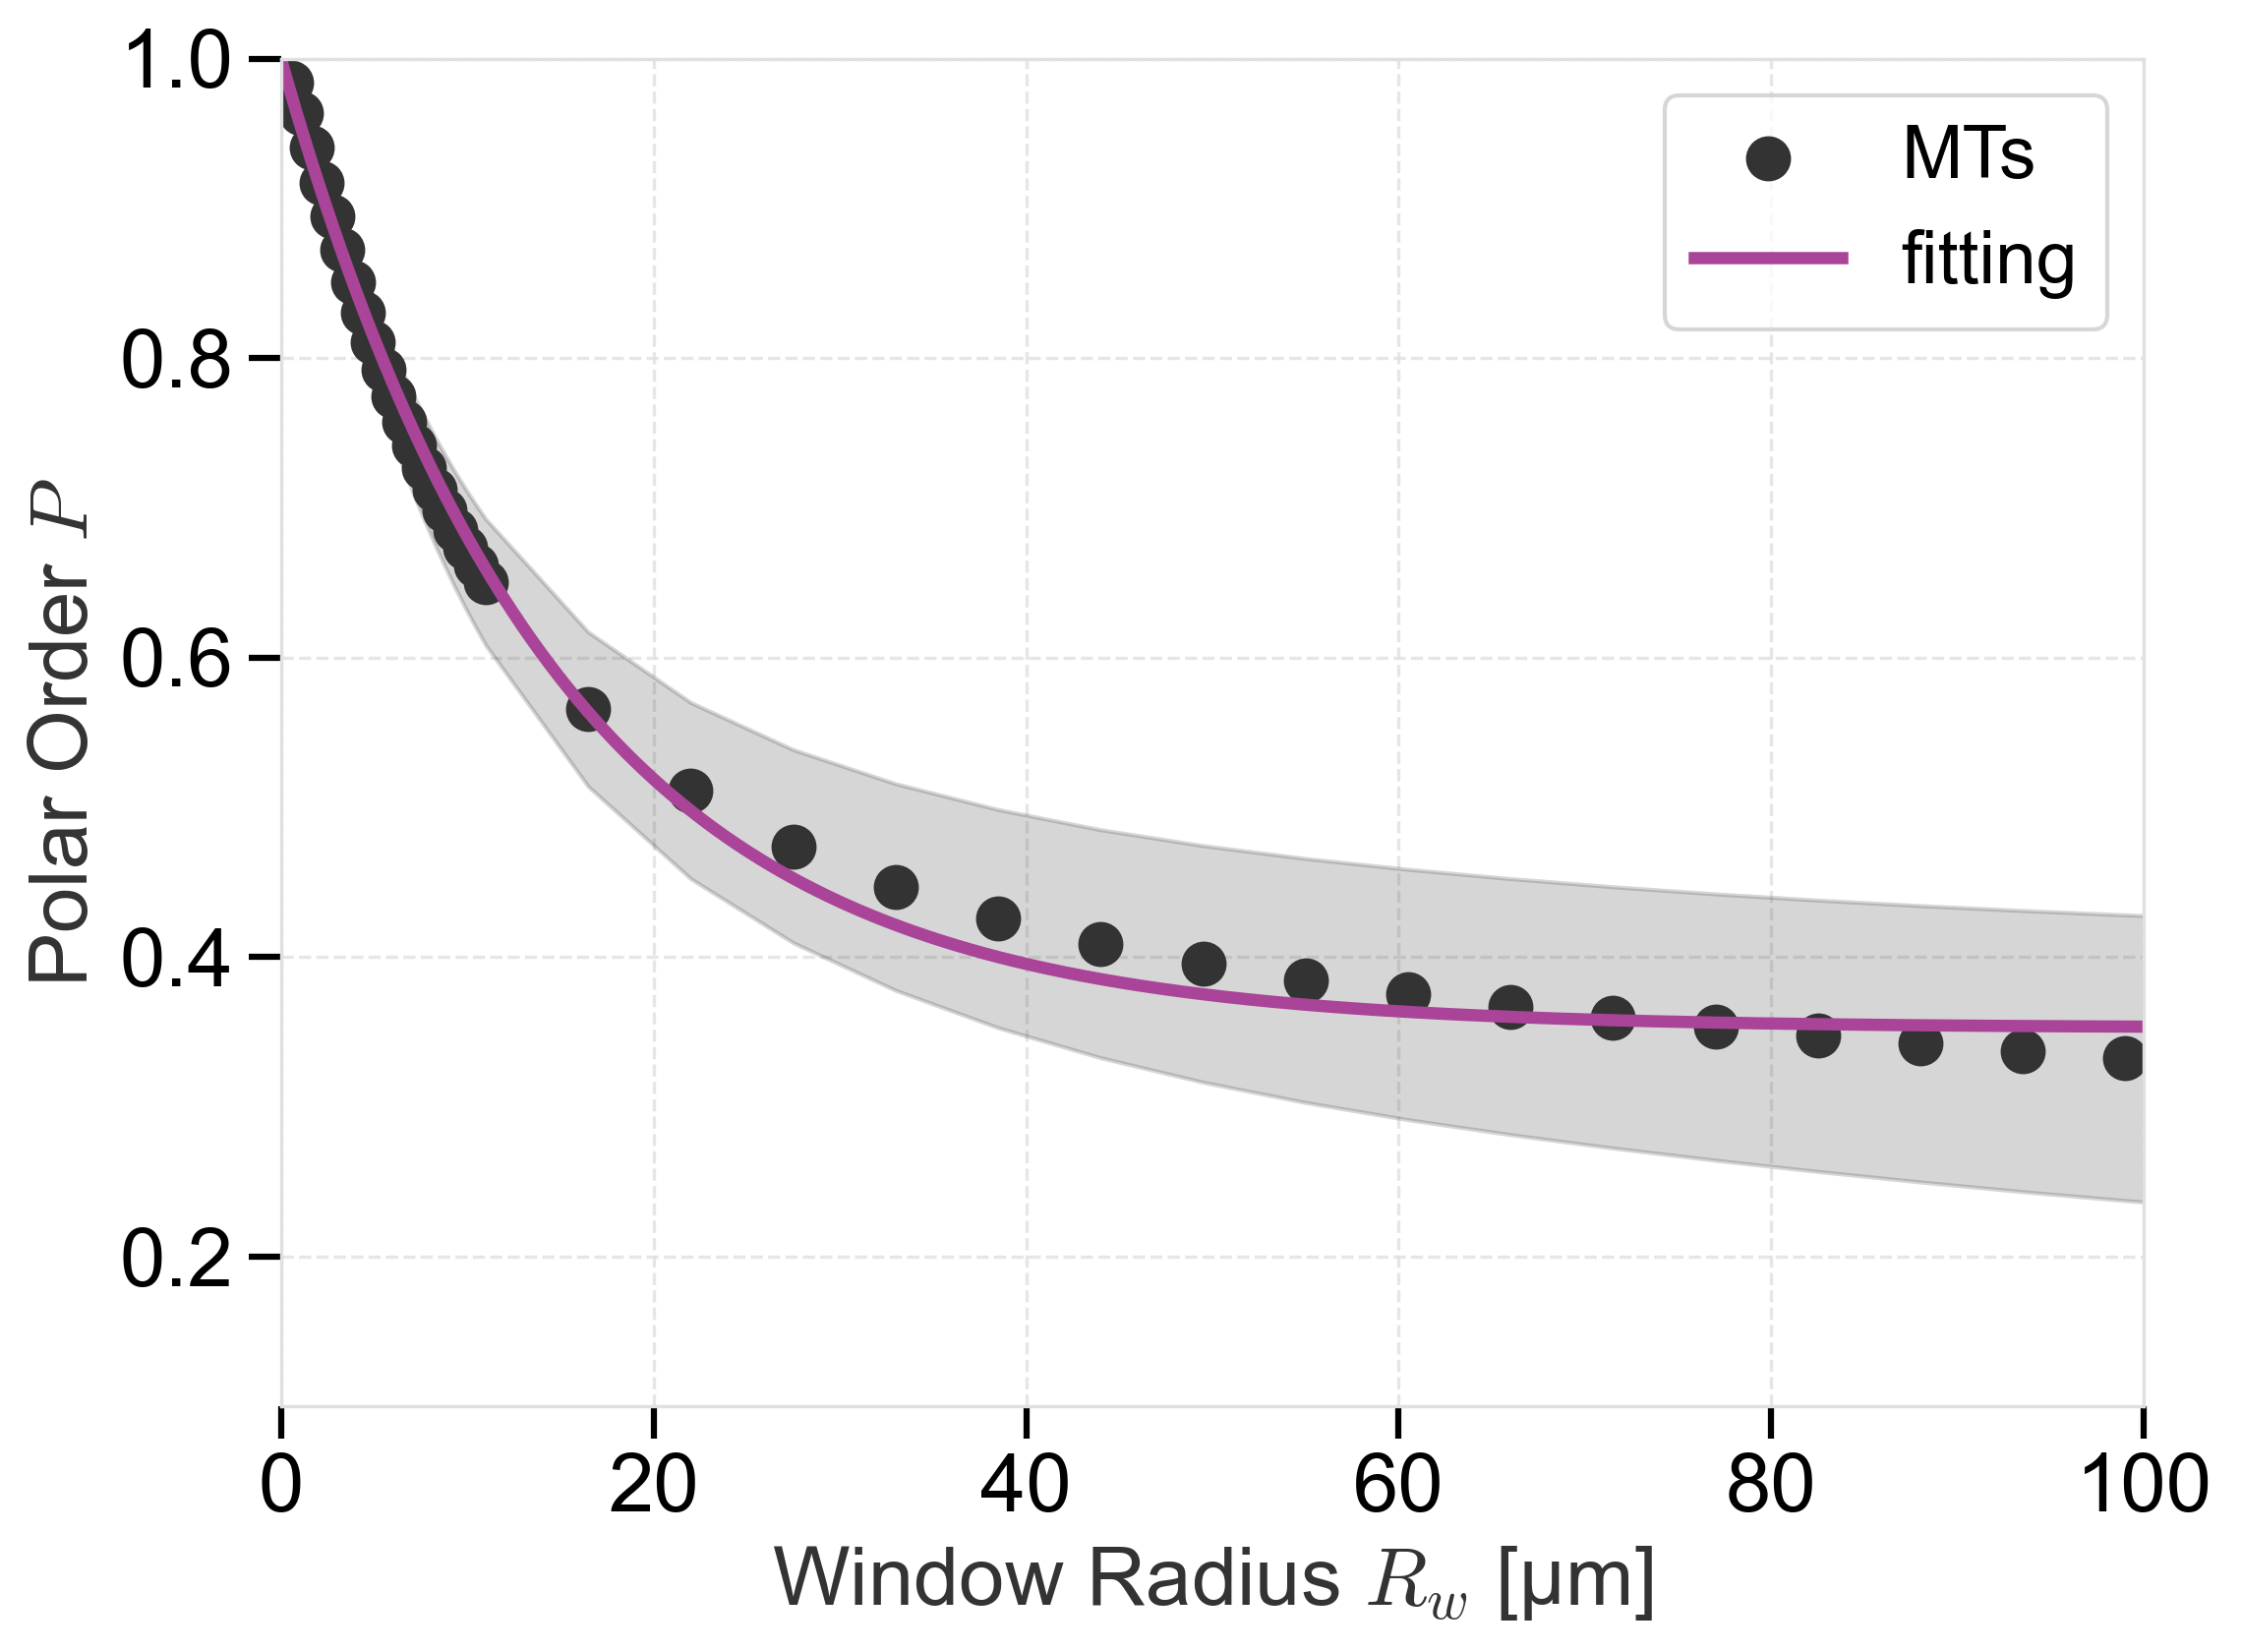

In [61]:
fig, ax = plt.subplots()

window_size, polar_order, popt, pcov = plot_polar_control(df_no, ax = ax, max_window=1000)

#print(f'A={popt[0]}, xi={popt[1]}, p0={popt[2]}')
print(f'xi={popt[0]}, p0={popt[1]}')

ax.set_xlabel('Window Radius $R_w$ [\u03bcm]')
ax.set_ylabel('Polar Order $P$')
ax.set_xlim(0,100)
ax.set_ylim(0.1,1)
#ax.set_yscale('log')
#ax.set_title('Polar Order vs Window Size')
ax.legend()

#fig.savefig(root / "figure" / "local_polar_control.svg")